# Smart Cities, Cooler Futures

## Urban Cooling Analysis

This project analyzes urban heat vulnerability across ten European cities and identifies which cities should be prioritised for urban cooling interventions.

### Selected Cities

- Berlin
- Athens
- Madrid
- Barcelona
- Milan
- Vienna
- Prague
- Budapest
- Lisbon
- Amsterdam

### Data Sources

1. Copernicus Urban Atlas 2021
2. Urban Atlas Street Tree Layer 2021
3. Population data (2021)
4. Urban Heat and Heatwave data (Map 2.5)
5. Copernicus IMDC imperviousness change data (2021–2024)

### Data Timeframe

We use 2021 as the baseline because it provides a consistent dataset across the main urban indicators.

We complement this baseline with 2021–2024 imperviousness change data to capture more recent urban changes that may influence future cooling priorities.

## 1. Project Setup

The project directories are defined first so that all datasets can be accessed consistently throughout the analysis.

### 1.1 Project Paths

The project directories are defined first so that all datasets can be accessed consistently throughout the analysis.

In [1]:
from pathlib import Path

import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

BASE_PATH = Path(
    "/Users/nedalgubran/Desktop/Project/Smart_Cities_Cooler_Futures"
)

DATA_PATH = BASE_PATH / "data_raw"

URBAN_ATLAS_PATH = DATA_PATH / "urban_atlas"
STREET_TREES_PATH = DATA_PATH / "street_trees"
POPULATION_PATH = DATA_PATH / "population"
HEAT_PATH = DATA_PATH / "heat"

print("Project:", BASE_PATH)
print("Data:", DATA_PATH)

Project: /Users/nedalgubran/Desktop/Project/Smart_Cities_Cooler_Futures
Data: /Users/nedalgubran/Desktop/Project/Smart_Cities_Cooler_Futures/data_raw


### 1.2 Define the Building Data Path

The building dataset is included as an additional data source for the urban cooling analysis.

The GHS-OBAT R2024A building data is stored in country-level folders within the `data_raw/Building/` directory.

In [2]:
# Define the Building data path

BUILDING_PATH = DATA_PATH / "Building"

print("Building data directory:")
print(BUILDING_PATH)

Building data directory:
/Users/nedalgubran/Desktop/Project/Smart_Cities_Cooler_Futures/data_raw/Building


### 1.3 Check Building Folder Contents

The Building data folder is checked to verify that the expected country-level datasets are available before starting the building analysis.

In [3]:
# Check Building country folders

print("Building folder contents:\n")

for item in sorted(BUILDING_PATH.iterdir()):
    if item.is_dir():
        print("-", item.name)

Building folder contents:

- GHS_OBAT_CSV_AUT_E2020_R2024A_V1_0
- GHS_OBAT_CSV_CZE_E2020_R2024A_V1_0
- GHS_OBAT_CSV_DEU_E2020_R2024A_V1_0
- GHS_OBAT_CSV_ESP_E2020_R2024A_V1_0
- GHS_OBAT_CSV_GRC_E2020_R2024A_V1_0
- GHS_OBAT_CSV_HUN_E2020_R2024A_V1_0
- GHS_OBAT_CSV_ITA_E2020_R2024A_V1_0
- GHS_OBAT_CSV_NLD_E2020_R2024A_V1_0
- GHS_OBAT_CSV_PRT_E2020_R2024A_V1_0


## 2. Urban Atlas

Urban Atlas 2021 provides detailed land use and land cover
information for the ten selected European cities.

The data is stored as FlatGeobuf (`.fgb`) files.

In [4]:
# Find Urban Atlas FGB files

fgb_files = sorted(URBAN_ATLAS_PATH.rglob("*.fgb"))

print(f"Found {len(fgb_files)} Urban Atlas files")

Found 10 Urban Atlas files


### 2.1 Urban Atlas Data Structure

Before combining the city datasets, we inspect one file
to understand the available variables and land-use classification.

In [5]:
# Inspect one Urban Atlas file

sample_gdf = gpd.read_file(fgb_files[0])

print("Shape:", sample_gdf.shape)
print("\nColumns:")
print(sample_gdf.columns.tolist())

display(sample_gdf.head())

Shape: (90323, 11)

Columns:
['country', 'fua_name', 'fua_code', 'code_2021', 'class_2021', 'prod_date', 'identifier', 'perimeter', 'area', 'comment', 'geometry']


,country,fua_name,fua_code,code_2021,class_2021,prod_date,identifier,perimeter,area,comment,geometry
0,AT,Wien,AT001L3,21000,Arable land (annual crops),2025-09,70626-AT001L3,584.488251,22755.177704,None,"MULTIPOLYGON (((4849627.919 2757717.629, 48496..."
1,AT,Wien,AT001L3,23000,Pastures,2025-09,84190-AT001L3,1805.337560,119901.961521,None,"MULTIPOLYGON (((4847684.504 2757187.15, 484768..."
2,AT,Wien,AT001L3,23000,Pastures,2025-09,84176-AT001L3,414.713551,10866.489328,None,"MULTIPOLYGON (((4847385.417 2757561.293, 48473..."
3,AT,Wien,AT001L3,23000,Pastures,2025-09,84186-AT001L3,780.743799,17642.653582,None,"MULTIPOLYGON (((4847588.642 2757102.584, 48475..."
4,AT,Wien,AT001L3,23000,Pastures,2025-09,83923-AT001L3,543.393359,12376.342939,None,"MULTIPOLYGON (((4841878.454 2755912.078, 48418..."


### 2.2 Combining Urban Atlas Data

The Urban Atlas datasets for the ten selected cities are combined
into a single GeoDataFrame.

The `city` column is retained to identify the origin of each record
and enable comparisons between cities.

In [6]:
# Combine Urban Atlas data for all cities

urban_atlas_data = []

for file in fgb_files:
    gdf = gpd.read_file(file)
    
    # Use the Functional Urban Area name as the city identifier
    gdf["city"] = gdf["fua_name"]
    
    urban_atlas_data.append(gdf)

urban_atlas = gpd.GeoDataFrame(
    pd.concat(urban_atlas_data, ignore_index=True),
    crs=urban_atlas_data[0].crs
)

print("Combined Urban Atlas shape:", urban_atlas.shape)
print("\nCities included:")
print(sorted(urban_atlas["city"].unique()))

Combined Urban Atlas shape: (790454, 12)

Cities included:
['Amsterdam', 'Athina', 'Barcelona', 'Berlin', 'Budapest', 'Lisboa', 'Madrid', 'Milano', 'Praha', 'Wien']


### 2.3 Urban Atlas Land-Use Classes

Urban Atlas classifies land use and land cover using standardized
codes for each Functional Urban Area.

We inspect the available classes before grouping them into broader
categories for the urban cooling analysis.

In [7]:
# Inspect Urban Atlas land-use classes

land_use_classes = (
    urban_atlas[["code_2021", "class_2021"]]
    .drop_duplicates()
    .sort_values("code_2021")
)

display(land_use_classes)

,code_2021,class_2021
122,11100,Continuous urban fabric (S.L. : > 80%)
94,11210,Discontinuous dense urban fabric (S.L. : 50% -...
164,11220,Discontinuous medium density urban fabric (S.L...
490,11230,Discontinuous low density urban fabric (S.L. :...
93,11240,Discontinuous very low density urban fabric (S...
345,11300,Isolated structures
5,12100,"Industrial, commercial, public, military and p..."
725,12210,Fast transit roads and associated land
1255,12220,Other roads and associated land
3618,12230,Railways and associated land


### 2.4 Green Space Classification

For the urban cooling analysis, Urban Atlas land-use classes are
grouped into broader categories.

Green-space areas include public, private, and unknown-access
green urban areas, as well as forests and natural herbaceous
vegetation.

These categories will be used to calculate the proportion of
green space within each city.

In [8]:
# Define Urban Atlas green-space classes

green_space_codes = [
    "14110",  # Green urban areas - Public access
    "14120",  # Green urban areas - Private access
    "14130",  # Green urban areas - Unknown access
    "31000",  # Forests
    "32000",  # Herbaceous vegetation associations
]

urban_atlas["green_space"] = urban_atlas["code_2021"].isin(
    green_space_codes
)

print("Green-space records:", urban_atlas["green_space"].sum())

Green-space records: 87994


### 2.4 Urban Atlas Code Validation

The Urban Atlas land-use codes are checked before defining the green-space classes.

In [9]:
# Check the data type and unique Urban Atlas codes

print("code_2021 data type:")
print(urban_atlas["code_2021"].dtype)

print("\nSample code values:")
print(urban_atlas["code_2021"].drop_duplicates().head(30).tolist())

code_2021 data type:
str

Sample code values:
['21000', '23000', '12100', '50000', '13100', '22000', '11240', '11210', '14200', '14110', '11100', '31000', '11220', '13400', '11300', '11230', '12210', '12220', '33000', '40000', '32000', '13300', '12230', '14130', '14120', '24000', '12400', '12300']


### 2.5 Green Space Area by City

The total area of identified green-space classes is calculated for each city.

In [10]:
# Calculate total green-space area by city

green_space_by_city = (
    urban_atlas[urban_atlas["green_space"]]
    .groupby("city")["area"]
    .sum()
    .sort_values(ascending=False)
)

display(green_space_by_city)

city
Berlin       3.639715e+09
Madrid       2.990688e+09
Wien         2.269757e+09
Praha        1.635195e+09
Lisboa       1.604253e+09
Budapest     1.553230e+09
Barcelona    1.277947e+09
Athina       9.276018e+08
Milano       3.092296e+08
Amsterdam    2.724769e+08
Name: area, dtype: float64

### 2.6 Area Unit Validation

The `area` field and geometry-derived area are compared to validate the measurement unit before converting areas to square kilometres.

In [11]:
# Check the area values and geometry CRS

print("CRS:", urban_atlas.crs)

print("\nArea statistics:")
print(urban_atlas["area"].describe())

CRS: EPSG:3035

Area statistics:
count    7.904540e+05
mean     6.853080e+04
std      9.202104e+05
min      1.857921e-01
25%      5.207567e+03
50%      1.141234e+04
75%      2.555906e+04
max      3.431194e+08
Name: area, dtype: float64


In [12]:
# Compare the area field with geometry-derived area

sample = urban_atlas.iloc[0]

print("Area field:", sample["area"])
print("Geometry area:", sample.geometry.area)

Area field: 22755.177704020094
Geometry area: 22755.177704020094


### 2.7 Green Space Area in km²

Urban Atlas area values are converted from square metres (m²) to square kilometres (km²) for easier interpretation and comparison.

In [13]:
# Calculate green-space area in square kilometres

green_space_by_city_km2 = (
    urban_atlas[urban_atlas["green_space"]]
    .groupby("city")["area"]
    .sum()
    .div(1_000_000)
    .sort_values(ascending=False)
)

display(green_space_by_city_km2)

city
Berlin       3639.715336
Madrid       2990.688215
Wien         2269.756597
Praha        1635.195480
Lisboa       1604.253378
Budapest     1553.230263
Barcelona    1277.947018
Athina        927.601791
Milano        309.229584
Amsterdam     272.476885
Name: area, dtype: float64

### 2.8 Green Space Percentage by City

To enable a fair comparison between cities of different sizes, we calculate the percentage of each city's Urban Atlas area classified as green space.

In [14]:
# Calculate total Urban Atlas area by city

total_area_by_city = (
    urban_atlas
    .groupby("city")["area"]
    .sum()
)

# Calculate green-space area by city

green_area_by_city = (
    urban_atlas[urban_atlas["green_space"]]
    .groupby("city")["area"]
    .sum()
)

# Calculate green-space percentage

green_space_percentage = (
    green_area_by_city
    .div(total_area_by_city)
    .mul(100)
    .sort_values(ascending=False)
)

display(green_space_percentage)

city
Barcelona    48.296473
Athina       47.222665
Berlin       40.156175
Madrid       37.972160
Lisboa       36.514981
Praha        28.370472
Budapest     24.274084
Wien         23.588846
Milano        9.927272
Amsterdam     8.189335
Name: area, dtype: float64

### 2.9 Urban Atlas Green Space Indicator

The green-space percentage is stored as a city-level indicator for comparison between cities.

In [15]:
# Create a city-level green-space indicator table

urban_atlas_indicators = (
    green_space_percentage
    .rename("green_space_pct")
    .reset_index()
)

urban_atlas_indicators

,city,green_space_pct
0,Barcelona,48.296473
1,Athina,47.222665
2,Berlin,40.156175
3,Madrid,37.972160
4,Lisboa,36.514981
5,Praha,28.370472
6,Budapest,24.274084
7,Wien,23.588846
8,Milano,9.927272
9,Amsterdam,8.189335


In [16]:
# Add green-space area in km²

urban_atlas_indicators["green_space_km2"] = (
    green_space_by_city_km2
    .reindex(urban_atlas_indicators["city"])
    .values
)

urban_atlas_indicators

,city,green_space_pct,green_space_km2
0,Barcelona,48.296473,1277.947018
1,Athina,47.222665,927.601791
2,Berlin,40.156175,3639.715336
3,Madrid,37.972160,2990.688215
4,Lisboa,36.514981,1604.253378
5,Praha,28.370472,1635.195480
6,Budapest,24.274084,1553.230263
7,Wien,23.588846,2269.756597
8,Milano,9.927272,309.229584
9,Amsterdam,8.189335,272.476885


## 3. Street Trees

Street tree data is used to complement the Urban Atlas green-space
indicator by providing information about trees located along urban
streets.

The ten selected European cities are analyzed consistently with
the Urban Atlas dataset.

### 3.1 Street Trees Data Structure

The Street Trees dataset provides street-tree information for the ten selected European cities.

The files are stored as FlatGeobuf (`.fgb`) files.

In [17]:
# Select one Street Trees FGB file for each city

street_tree_files = sorted(
    [
        file for file in STREET_TREES_PATH.rglob("*.fgb")
        if file.parent != STREET_TREES_PATH
    ]
)

print(f"Found {len(street_tree_files)} city-level Street Trees files:\n")

for file in street_tree_files:
    print(file)

Found 20 city-level Street Trees files:

/Users/nedalgubran/Desktop/Project/Smart_Cities_Cooler_Futures/data_raw/street_trees/Athina/CLMS_UA_STL_S2021_V005ha_EL001L1_ATHINA_03035_V01_R02_20251121.fgb
/Users/nedalgubran/Desktop/Project/Smart_Cities_Cooler_Futures/data_raw/street_trees/Athina/CLMS_UA_UM_S2021_V005ha_EL001L1_ATHINA_03035_V01_R02_20251121.fgb
/Users/nedalgubran/Desktop/Project/Smart_Cities_Cooler_Futures/data_raw/street_trees/Berlin/CLMS_UA_STL_S2021_V005ha_DE001L1_BERLIN_03035_V01_R02_20251121.fgb
/Users/nedalgubran/Desktop/Project/Smart_Cities_Cooler_Futures/data_raw/street_trees/Berlin/CLMS_UA_UM_S2021_V005ha_DE001L1_BERLIN_03035_V01_R02_20251121.fgb
/Users/nedalgubran/Desktop/Project/Smart_Cities_Cooler_Futures/data_raw/street_trees/CLMS_UA_STL_S2021_V005ha_CZ001L2_PRAHA_03035_V01_R02_20251121/CLMS_UA_STL_S2021_V005ha_CZ001L2_PRAHA_03035_V01_R02_20251121.fgb
/Users/nedalgubran/Desktop/Project/Smart_Cities_Cooler_Futures/data_raw/street_trees/CLMS_UA_STL_S2021_V005ha_CZ

In [18]:
# Inspect one Street Trees file

sample_street_trees = gpd.read_file(street_tree_files[0])

print("Shape:", sample_street_trees.shape)

print("\nCRS:", sample_street_trees.crs)

print("\nColumns:")
print(sample_street_trees.columns.tolist())

display(sample_street_trees.head())

Shape: (25375, 7)

CRS: EPSG:3035

Columns:
['area', 'perimeter', 'country', 'fua_code', 'fua_name', 'STL', 'geometry']


,area,perimeter,country,fua_code,fua_name,STL,geometry
0,537.5,136.148276,EL,EL001L1,ATHINA,1,"MULTIPOLYGON (((5563503.876 1737212.827, 55634..."
1,600.0,123.027756,EL,EL001L1,ATHINA,1,"MULTIPOLYGON (((5563618.876 1737352.827, 55636..."
2,1362.5,163.087106,EL,EL001L1,ATHINA,1,"MULTIPOLYGON (((5562928.876 1737482.827, 55629..."
3,1225.0,172.503869,EL,EL001L1,ATHINA,1,"MULTIPOLYGON (((5562998.876 1737307.827, 55630..."
4,1187.5,146.534064,EL,EL001L1,ATHINA,1,"MULTIPOLYGON (((5562898.876 1737182.827, 55629..."


### 3.2 Street Trees File Inspection

Before combining the city datasets, we inspect one file to verify its structure, attributes, and coordinate reference system.

In [19]:
# Inspect one Street Trees file

sample_street_trees = gpd.read_file(street_tree_files[0])

print("Shape:", sample_street_trees.shape)
print("\nCRS:", sample_street_trees.crs)
print("\nColumns:")
print(sample_street_trees.columns.tolist())

display(sample_street_trees.head())

Shape: (25375, 7)

CRS: EPSG:3035

Columns:
['area', 'perimeter', 'country', 'fua_code', 'fua_name', 'STL', 'geometry']


,area,perimeter,country,fua_code,fua_name,STL,geometry
0,537.5,136.148276,EL,EL001L1,ATHINA,1,"MULTIPOLYGON (((5563503.876 1737212.827, 55634..."
1,600.0,123.027756,EL,EL001L1,ATHINA,1,"MULTIPOLYGON (((5563618.876 1737352.827, 55636..."
2,1362.5,163.087106,EL,EL001L1,ATHINA,1,"MULTIPOLYGON (((5562928.876 1737482.827, 55629..."
3,1225.0,172.503869,EL,EL001L1,ATHINA,1,"MULTIPOLYGON (((5562998.876 1737307.827, 55630..."
4,1187.5,146.534064,EL,EL001L1,ATHINA,1,"MULTIPOLYGON (((5562898.876 1737182.827, 55629..."


### 3.3 Combining Street Trees Data

The Street Trees datasets for the ten selected European cities are combined into a single GeoDataFrame.

The `fua_name` field is retained to identify the corresponding city for city-level aggregation and comparison.

In [20]:
# Combine Street Trees data for all ten cities

street_tree_data = []

for file in street_tree_files:
    gdf = gpd.read_file(file)
    street_tree_data.append(gdf)

street_trees = gpd.GeoDataFrame(
    pd.concat(street_tree_data, ignore_index=True),
    crs=street_tree_data[0].crs
)

print("Combined Street Trees shape:", street_trees.shape)

print("\nCities included:")
print(
    sorted(
        street_trees["fua_name"]
        .dropna()
        .astype(str)
        .str.upper()
        .unique()
    )
)

Combined Street Trees shape: (532898, 8)

Cities included:
['AMSTERDAM', 'ATHINA', 'BARCELONA', 'BERLIN', 'BUDAPEST', 'LISBOA', 'MADRID', 'MILANO', 'PRAHA', 'WIEN']


### 3.4 Street Tree Area by City

The total area of street-tree features is aggregated for each city.

This provides a city-level measure of street-tree coverage and complements the broader green-space indicator derived from Urban Atlas.

In [21]:
# Calculate total street-tree area by city

street_tree_area_by_city = (
    street_trees
    .groupby("fua_name")["area"]
    .sum()
    .sort_values(ascending=False)
)

display(street_tree_area_by_city)

fua_name
BERLIN       529384262.5
BUDAPEST     272653000.0
PRAHA        196415950.0
WIEN         185659150.0
MADRID       164719537.5
MILANO       149984612.5
AMSTERDAM    140381650.0
BARCELONA    101012187.5
LISBOA        81106900.0
ATHINA        63926837.5
Name: area, dtype: float64

### 3.5 Street Trees Area Validation

Before calculating city-level street-tree indicators, we validate the area measurements and coordinate reference system used by the Street Trees dataset.

In [22]:
# Validate Street Trees area measurements

print("CRS:", street_trees.crs)

print("\nArea statistics:")
print(street_trees["area"].describe())

# Compare the stored area with the geometry area for one feature
sample = street_trees.iloc[0]

print("\nSample area check:")
print("Area field:", sample["area"])
print("Geometry area:", sample.geometry.area)

CRS: EPSG:3035

Area statistics:
count    4.538990e+05
mean     4.153444e+03
std      6.928396e+04
min      5.000000e+02
25%      7.625000e+02
50%      1.250000e+03
75%      2.587500e+03
max      3.262756e+07
Name: area, dtype: float64

Sample area check:
Area field: 537.5
Geometry area: 537.5


### 3.6 Street Tree Area in km²

Street Trees area values are converted from square metres (m²) to square kilometres (km²) for easier interpretation and comparison.

In [23]:
# Calculate total street-tree area in square kilometres

street_tree_area_km2 = (
    street_trees
    .groupby("fua_name")["area"]
    .sum()
    .div(1_000_000)
    .sort_values(ascending=False)
)

display(street_tree_area_km2)

fua_name
BERLIN       529.384262
BUDAPEST     272.653000
PRAHA        196.415950
WIEN         185.659150
MADRID       164.719538
MILANO       149.984612
AMSTERDAM    140.381650
BARCELONA    101.012187
LISBOA        81.106900
ATHINA        63.926837
Name: area, dtype: float64

### 3.7 Street Tree Percentage by City

To enable a comparable assessment across cities of different sizes, street-tree area is expressed as a percentage of the corresponding Urban Atlas area.

In [24]:
# Calculate total Urban Atlas area by city in km²

total_area_km2 = (
    urban_atlas
    .groupby("city")["area"]
    .sum()
    .div(1_000_000)
)

# Calculate street-tree percentage

street_tree_percentage = (
    street_tree_area_km2
    .div(total_area_km2.rename(index=str.upper))
    .mul(100)
    .sort_values(ascending=False)
)

display(street_tree_percentage)

fua_name
BERLIN       5.840580
MILANO       4.814992
BUDAPEST     4.261056
AMSTERDAM    4.219192
BARCELONA    3.817476
PRAHA        3.407796
ATHINA       3.254409
MADRID       2.091410
WIEN         1.929496
LISBOA       1.846103
Name: area, dtype: float64

### 3.8 Urban Green and Street Tree Indicators

The Urban Atlas green-space and Street Tree indicators are combined into a single city-level table.

This table will serve as the basis for integrating the Population and Heat indicators.

In [25]:
# Create a city-level Street Tree indicator table

street_tree_indicators = (
    street_tree_percentage
    .rename("street_tree_pct")
    .reset_index()
    .rename(columns={"fua_name": "city"})
)

# Standardize city names for merging

urban_atlas_indicators["city"] = (
    urban_atlas_indicators["city"].str.upper()
)

street_tree_indicators["city"] = (
    street_tree_indicators["city"].str.upper()
)

# Merge Urban Atlas and Street Tree indicators

city_green_indicators = urban_atlas_indicators.merge(
    street_tree_indicators,
    on="city",
    how="inner"
)

display(city_green_indicators.sort_values("green_space_pct", ascending=False))

,city,green_space_pct,green_space_km2,street_tree_pct
0,BARCELONA,48.296473,1277.947018,3.817476
1,ATHINA,47.222665,927.601791,3.254409
2,BERLIN,40.156175,3639.715336,5.840580
3,MADRID,37.972160,2990.688215,2.091410
4,LISBOA,36.514981,1604.253378,1.846103
5,PRAHA,28.370472,1635.195480,3.407796
6,BUDAPEST,24.274084,1553.230263,4.261056
7,WIEN,23.588846,2269.756597,1.929496
8,MILANO,9.927272,309.229584,4.814992
9,AMSTERDAM,8.189335,272.476885,4.219192


### 3.9 Green and Street Tree Indicators

The combined city-level table summarizes two complementary urban vegetation indicators:

- `green_space_pct`: percentage of the Urban Atlas area classified as green space.
- `street_tree_pct`: percentage of the Urban Atlas area covered by Street Tree Layer features.

These indicators will later be combined with population and heat data to assess urban cooling conditions.

## 4. Population

Population data is used to provide demographic context for the urban cooling analysis.

The population indicator is aligned with the same ten selected European cities used in the Urban Atlas and Street Trees analysis.

### 4.1 Population Data Structure

Before calculating the population indicator, we inspect the available population files and identify the data needed for the analysis.

In [26]:
population_raster = (
    POPULATION_PATH
    / "JRC-ESTAT_Census_Population_2021_100m_rev0726.tif"
)

print("Population raster exists:", population_raster.exists())

Population raster exists: True


### 4.2 Population Raster Structure

The population dataset is provided as a 100 m raster grid for the 2021 census reference period.

We inspect the raster dimensions, coordinate reference system, resolution, and NoData value before extracting population by city.

In [27]:
import rasterio

population_raster = (
    POPULATION_PATH
    / "JRC-ESTAT_Census_Population_2021_100m_rev0726.tif"
)

with rasterio.open(population_raster) as src:
    print("CRS:", src.crs)
    print("Width:", src.width)
    print("Height:", src.height)
    print("Resolution:", src.res)
    print("Bounds:", src.bounds)
    print("Data type:", src.dtypes[0])
    print("NoData value:", src.nodata)

CRS: EPSG:3035
Width: 55620
Height: 44750
Resolution: (100.0, 100.0)
Bounds: BoundingBox(left=943000.0, bottom=941000.0, right=6505000.0, top=5416000.0)
Data type: int16
NoData value: -1.0


### 4.3 Population Extraction by City

The 100 m population raster is spatially matched with the
Functional Urban Area boundaries from Urban Atlas.

For each city, the population values of raster cells within
the FUA boundary are summed to obtain a city-level population
indicator for the 2021 reference period.

In [28]:
# 4.3 Population Extraction by City

from rasterio.features import rasterize
from rasterio.windows import from_bounds

population_by_city = {}

with rasterio.open(population_raster) as src:

    for city in sorted(urban_atlas["city"].unique()):

        print(f"Processing {city}...")

        city_gdf = urban_atlas.loc[
            urban_atlas["city"] == city,
            ["geometry"]
        ].copy()

        # Simplify geometries to match the 100 m raster resolution
        city_gdf["geometry"] = city_gdf.geometry.simplify(
            tolerance=50,
            preserve_topology=True
        )

        # Bounding box
        minx, miny, maxx, maxy = city_gdf.total_bounds

        window = from_bounds(
            minx, miny, maxx, maxy,
            transform=src.transform
        ).round_offsets().round_lengths()

        population_array = src.read(
            1,
            window=window
        )

        window_transform = src.window_transform(window)

        # Rasterize the simplified Urban Atlas polygons
        city_mask = rasterize(
            [(geom, 1) for geom in city_gdf.geometry if not geom.is_empty],
            out_shape=population_array.shape,
            transform=window_transform,
            fill=0,
            dtype="uint8"
        )

        valid = (
            (city_mask == 1) &
            (population_array != src.nodata)
        )

        population_by_city[city] = population_array[valid].sum()

        print(f"Population: {population_by_city[city]:,.0f}")

population_by_city = pd.Series(
    population_by_city,
    name="population_2021"
)

display(
    population_by_city.sort_values(ascending=False)
)

Processing Amsterdam...


/opt/miniconda3/lib/python3.13/site-packages/shapely/constructive.py:1177: RuntimeWarning: invalid value encountered in simplify_preserve_topology
  return lib.simplify_preserve_topology(geometry, tolerance, **kwargs)


Population: 2,682,860
Processing Athina...


/opt/miniconda3/lib/python3.13/site-packages/shapely/constructive.py:1177: RuntimeWarning: invalid value encountered in simplify_preserve_topology
  return lib.simplify_preserve_topology(geometry, tolerance, **kwargs)


Population: 3,418,170
Processing Barcelona...


...

/opt/miniconda3/lib/python3.13/site-packages/shapely/constructive.py:1177: RuntimeWarning: invalid value encountered in simplify_preserve_topology
  return lib.simplify_preserve_topology(geometry, tolerance, **kwargs)


Population: 2,088,432
Processing Wien...


/opt/miniconda3/lib/python3.13/site-packages/shapely/constructive.py:1177: RuntimeWarning: invalid value encountered in simplify_preserve_topology
  return lib.simplify_preserve_topology(geometry, tolerance, **kwargs)


Population: 2,840,721


Madrid       6507965
Barcelona    4767556
Milano       4609706
Berlin       4595309
Athina       3418170
Budapest     2842187
Wien         2840721
Lisboa       2743699
Amsterdam    2682860
Praha        2088432
Name: population_2021, dtype: int64

### 4.4 City-Level Population Indicator

The extracted 2021 population values are converted into a
city-level table and will later be combined with the urban
green-space and street-tree indicators.

In [29]:
# Create city-level population indicator table

population_indicators = (
    population_by_city
    .rename("population_2021")
    .reset_index()
    .rename(columns={"index": "city"})
)

# Standardize city names for merging
population_indicators["city"] = (
    population_indicators["city"]
    .str.upper()
)

display(
    population_indicators
    .sort_values("population_2021", ascending=False)
)

,city,population_2021
6,MADRID,6507965
2,BARCELONA,4767556
7,MILANO,4609706
3,BERLIN,4595309
1,ATHINA,3418170
4,BUDAPEST,2842187
9,WIEN,2840721
5,LISBOA,2743699
0,AMSTERDAM,2682860
8,PRAHA,2088432


### 4.5 Combined City Indicators

The population indicator is combined with the Urban Atlas
green-space and Street Tree indicators to create a unified
city-level dataset for the ten selected cities.

In [30]:
# Merge population with green-space and street-tree indicators

city_indicators = city_green_indicators.merge(
    population_indicators,
    on="city",
    how="inner"
)

display(
    city_indicators
    .sort_values("population_2021", ascending=False)
)

,city,green_space_pct,green_space_km2,street_tree_pct,population_2021
3,MADRID,37.972160,2990.688215,2.091410,6507965
0,BARCELONA,48.296473,1277.947018,3.817476,4767556
8,MILANO,9.927272,309.229584,4.814992,4609706
2,BERLIN,40.156175,3639.715336,5.840580,4595309
1,ATHINA,47.222665,927.601791,3.254409,3418170
6,BUDAPEST,24.274084,1553.230263,4.261056,2842187
7,WIEN,23.588846,2269.756597,1.929496,2840721
4,LISBOA,36.514981,1604.253378,1.846103,2743699
9,AMSTERDAM,8.189335,272.476885,4.219192,2682860
5,PRAHA,28.370472,1635.195480,3.407796,2088432


## 5. Urban Heat

The heat dataset is based on EEA Map 2.5 and provides two
complementary indicators related to urban heat:

- urban heat island intensity
- heatwave-related exposure

The two indicators will be inspected and aggregated at city level
before being combined with the environmental and population data.

### 5.1 Heat Data Structure

Before extracting the heat indicators, we inspect the available
heat layers and their spatial attributes.

The heat dataset contains two complementary layers:

- `Map_2_5_intensity`
- `Map_2_5_heatwaves`

### 5.2 Heat Layer Inspection

The EEA Map 2.5 dataset contains two spatial heat layers:

- `Map_2_5_intensity`: urban heat island intensity
- `Map_2_5_heatwaves`: heatwave-related information

We inspect both layers to identify their attributes, coordinate
reference system, and spatial structure before aggregating the
heat indicators by city.

In [31]:
# Define the two heat shapefiles

HEAT_DATA_PATH = HEAT_PATH / "Map2.5-120001" / "data"

heatwaves_path = HEAT_DATA_PATH / "Map_2_5_heatwaves.shp"
intensity_path = HEAT_DATA_PATH / "Map_2_5_intensity.shp"

print("Heatwaves exists:", heatwaves_path.exists())
print("Intensity exists:", intensity_path.exists())

Heatwaves exists: True
Intensity exists: True


In [32]:
# Read both heat layers

heatwaves = gpd.read_file(heatwaves_path)
intensity = gpd.read_file(intensity_path)

print("Heatwaves shape:", heatwaves.shape)
print("Intensity shape:", intensity.shape)

print("\nHeatwaves CRS:", heatwaves.crs)
print("Intensity CRS:", intensity.crs)

print("\nHeatwaves columns:")
print(heatwaves.columns.tolist())

print("\nIntensity columns:")
print(intensity.columns.tolist())

Heatwaves shape: (154, 6)
Intensity shape: (100, 6)

Heatwaves CRS: EPSG:3035
Intensity CRS: EPSG:3035

Heatwaves columns:
['OBJECTID', 'Id', 'hw85_20_52', 'Shape_Leng', 'Shape_Area', 'geometry']

Intensity columns:
['OBJECTID_1', 'OBJECTID', 'Column1', 'Column2', 'Column3', 'geometry']


### 5.3 Heat Attribute Inspection

The heat layers contain several attribute fields. Their values are
inspected before selecting the variables used in the city-level
heat indicators.

This step helps ensure that the analysis uses the correct heat
intensity and heatwave variables from the EEA Map 2.5 dataset.

In [33]:
# Inspect Heatwaves attributes

print("Heatwaves:")
display(heatwaves.head())

print("\nHeatwaves descriptive statistics:")
display(heatwaves.describe())

Heatwaves:


,OBJECTID,Id,hw85_20_52,Shape_Leng,Shape_Area,geometry
0,1,1,5.0,538399.184415,1.204751e+10,"POLYGON ((5692093.438 6008708.517, 5645357.918..."
1,2,2,1.5,539171.641354,1.204753e+10,"POLYGON ((5737530.076 6047571.912, 5692093.438..."
2,3,3,1.5,677258.814874,2.671955e+10,"POLYGON ((5645357.918 5971175.419, 5692093.438..."
3,4,4,0.0,567855.596588,1.603769e+10,"POLYGON ((4575723.655 4923741.954, 4556303.062..."
4,5,5,0.0,877865.234738,4.805947e+10,"POLYGON ((6173889.73 5578598.116, 5988898.265 ..."



Heatwaves descriptive statistics:


,OBJECTID,Id,hw85_20_52,Shape_Leng,Shape_Area
count,154.000000,154.000000,154.000000,1.540000e+02,1.540000e+02
mean,77.500000,82.214286,2.444805,1.209784e+06,7.833404e+10
std,44.600075,45.854126,2.130974,1.608517e+06,1.528157e+11
min,1.000000,1.000000,0.000000,5.383992e+05,1.204751e+10
25%,39.250000,44.250000,1.000000,6.894657e+05,2.821925e+10
50%,77.500000,82.500000,1.500000,7.395485e+05,3.371919e+10
75%,115.750000,120.750000,3.875000,1.208514e+06,7.227208e+10
max,154.000000,162.000000,9.500000,1.550216e+07,1.271231e+12


In [34]:
# Inspect Heat Intensity values

display(intensity.head(10))

print("\nUnique values:")
for column in ["Column1", "Column2", "Column3"]:
    print(f"\n{column}:")
    print(intensity[column].unique())

,OBJECTID_1,OBJECTID,Column1,Column2,Column3,geometry
0,1,1,-0.477337,38.362244,1.071040,POINT Z (3402258.625 1760840.363 1.071)
1,2,2,4.896728,52.364805,1.446170,POINT Z (3973698.674 3262772.191 1.446)
2,3,3,4.402000,51.246000,1.243220,POINT Z (3930553.314 3141075.188 1.243)
3,4,4,23.728056,37.983889,2.101180,POINT Z (5528466.128 1764761.749 2.101)
4,5,5,2.132641,41.384404,1.370220,POINT Z (3661587.218 2065827.861 1.37)
5,6,6,16.838012,41.122724,0.723279,POINT Z (4896838.966 2028577.647 0.723)
6,7,7,7.593117,47.561912,1.461090,POINT Z (4139786.084 2719423.963 1.461)
7,8,8,20.402604,44.813520,1.481330,POINT Z (5142343.508 2468663.147 1.481)
8,9,9,13.410963,52.518918,1.730470,POINT Z (4552446.382 3273166.94 1.731)
9,10,10,-2.935181,43.290576,0.953347,POINT Z (3274279.494 2332983.716 0.953)



Unique values:

Column1:
[ -0.477337   4.896728   4.402     23.728056   2.132641  16.838012
   7.593117  20.402604  13.410963  -2.935181  -1.890053  11.34
  -0.589243  25.599566  17.107493   4.372324  26.094118  19.130742
   4.438581  23.611003   6.960652  12.548072  21.62465   -6.255537
   6.813655  -3.207494   8.662606  18.629768   6.131886   8.892778
   3.721534  -4.252269  11.976238  15.4387    17.663482   9.992417
  24.940881  21.155161  21.259439  19.962318  -1.546576  12.36214
   5.578524   3.059346  -9.139197  14.507329  19.456031  -0.128112
   6.134812   4.834777  -3.701233  -4.421466   5.42848    9.186554
  20.750072   3.875541  11.549651  -1.129746  -1.547028  14.257146
  -1.597418   7.2618    19.838109  10.751806  11.880276  13.351948
   2.648789   2.354478  18.241645  19.260349  -8.564352  14.417385
 -21.829103  24.122843  12.478823   4.448164  18.35813   -5.981022
  21.427797  23.325154  16.463501  18.066585   7.739025  20.147325
  24.757052  26.731857  22.952908  19.794

### 5.4 Urban Heat Island Intensity

The `Map_2_5_intensity` layer contains point-based Urban Heat Island
(UHI) intensity information for European cities.

The spatial coordinates are stored in `Column1` and `Column2`,
while `Column3` represents UHI intensity in degrees Celsius.

The UHI intensity indicator is based on the spatial 90th percentile
(P90) UHI intensity for each city.

In [35]:
# Rename the heat intensity columns for clarity

heat_intensity = intensity.rename(
    columns={
        "Column1": "longitude",
        "Column2": "latitude",
        "Column3": "uhi_intensity_c"
    }
)

display(
    heat_intensity[
        ["longitude", "latitude", "uhi_intensity_c", "geometry"]
    ].head(10)
)

,longitude,latitude,uhi_intensity_c,geometry
0,-0.477337,38.362244,1.071040,POINT Z (3402258.625 1760840.363 1.071)
1,4.896728,52.364805,1.446170,POINT Z (3973698.674 3262772.191 1.446)
2,4.402000,51.246000,1.243220,POINT Z (3930553.314 3141075.188 1.243)
3,23.728056,37.983889,2.101180,POINT Z (5528466.128 1764761.749 2.101)
4,2.132641,41.384404,1.370220,POINT Z (3661587.218 2065827.861 1.37)
5,16.838012,41.122724,0.723279,POINT Z (4896838.966 2028577.647 0.723)
6,7.593117,47.561912,1.461090,POINT Z (4139786.084 2719423.963 1.461)
7,20.402604,44.813520,1.481330,POINT Z (5142343.508 2468663.147 1.481)
8,13.410963,52.518918,1.730470,POINT Z (4552446.382 3273166.94 1.731)
9,-2.935181,43.290576,0.953347,POINT Z (3274279.494 2332983.716 0.953)


### 5.5 Assign Heat Intensity to Cities

The UHI intensity points are spatially matched with the selected
Functional Urban Areas to identify the corresponding city.

This produces one city-level UHI intensity value for the selected
cities.

In [36]:
# Match UHI intensity points to the Urban Atlas city polygons

heat_city = gpd.sjoin(
    heat_intensity[
        ["uhi_intensity_c", "geometry"]
    ],
    urban_atlas[
        ["city", "geometry"]
    ],
    how="left",
    predicate="within"
)

# Keep one record per city

heat_city_indicators = (
    heat_city[
        ["city", "uhi_intensity_c"]
    ]
    .dropna(subset=["city"])
    .drop_duplicates(subset=["city"])
)

display(
    heat_city_indicators.sort_values("city")
)

,city,uhi_intensity_c
1,Amsterdam,1.44617
3,Athina,2.10118
4,Barcelona,1.37022
8,Berlin,1.73047
17,Budapest,1.99352
50,Madrid,1.72486
53,Milano,2.00832
71,Praha,1.70673
94,Wien,1.65995


### 5.6 Validate Heat–City Matching

The spatial join successfully matched the UHI intensity points to
nine of the ten selected cities.

Lisboa was not matched and therefore requires additional validation
before the final city-level heat indicator is created.

In [37]:
# Check which cities are missing from the UHI intensity match

selected_cities = set(
    urban_atlas["city"].str.upper().unique()
)

matched_cities = set(
    heat_city_indicators["city"].str.upper().unique()
)

missing_cities = sorted(selected_cities - matched_cities)

print("Missing cities:", missing_cities)

Missing cities: ['LISBOA']


### 5.6 Validate Lisboa Heat–City Matching

The spatial join matched nine of the ten selected cities.

Lisboa was not matched, so its heat-intensity point is inspected
directly using the longitude and latitude attributes provided
in the EEA heat layer.

In [38]:
# Inspect heat-intensity points around Lisboa

lisboa_candidates = heat_intensity[
    heat_intensity["longitude"].between(-10, -8) &
    heat_intensity["latitude"].between(38, 39.5)
][
    ["longitude", "latitude", "uhi_intensity_c", "geometry"]
]

display(lisboa_candidates)

,longitude,latitude,uhi_intensity_c,geometry
44,-9.139197,38.695177,1.11103,POINT Z (2664852.639 1943834.996 1.111)


### 5.7 Final UHI Intensity Indicator

The UHI intensity layer contains one representative intensity value
for each European city.

Lisboa was not captured by the polygon-based spatial join, so its
official heat point was validated directly using its longitude and
latitude and added to the city-level indicator.

In [39]:
# Add the validated Lisboa heat-intensity value

lisboa_heat = pd.DataFrame({
    "city": ["Lisboa"],
    "uhi_intensity_c": [1.11103]
})

# Standardize city names
heat_city_indicators["city"] = (
    heat_city_indicators["city"].str.title()
)

# Add Lisboa
heat_city_indicators = pd.concat(
    [heat_city_indicators, lisboa_heat],
    ignore_index=True
)

# Remove duplicates and sort
heat_city_indicators = (
    heat_city_indicators
    .drop_duplicates(subset="city")
    .sort_values("city")
    .reset_index(drop=True)
)

display(heat_city_indicators)

,city,uhi_intensity_c
0,Amsterdam,1.44617
1,Athina,2.10118
2,Barcelona,1.37022
3,Berlin,1.73047
4,Budapest,1.99352
5,Lisboa,1.11103
6,Madrid,1.72486
7,Milano,2.00832
8,Praha,1.70673
9,Wien,1.65995


### 5.8 Heatwave Indicator

The `Map_2_5_heatwaves` layer provides a heatwave-related indicator
for the selected European cities.

The variable `hw85_20_52` is inspected and matched to the selected
cities before being incorporated into the final city-level dataset.

In [40]:
# Inspect heatwave values

heatwaves_selected = heatwaves[
    ["Id", "hw85_20_52", "geometry"]
].copy()

print("Heatwave value range:")
print(heatwaves_selected["hw85_20_52"].describe())

display(
    heatwaves_selected.head(10)
)

Heatwave value range:
count    154.000000
mean       2.444805
std        2.130974
min        0.000000
25%        1.000000
50%        1.500000
75%        3.875000
max        9.500000
Name: hw85_20_52, dtype: float64


,Id,hw85_20_52,geometry
0,1,5.0,"POLYGON ((5692093.438 6008708.517, 5645357.918..."
1,2,1.5,"POLYGON ((5737530.076 6047571.912, 5692093.438..."
2,3,1.5,"POLYGON ((5645357.918 5971175.419, 5692093.438..."
3,4,0.0,"POLYGON ((4575723.655 4923741.954, 4556303.062..."
4,5,0.0,"POLYGON ((6173889.73 5578598.116, 5988898.265 ..."
5,7,0.0,"POLYGON ((5675265.501 5006428.332, 5518086.105..."
6,8,0.0,"POLYGON ((4613685.465 4512248.546, 4520904.752..."
7,9,1.5,"POLYGON ((4706220.493 4521273.482, 4613685.465..."
8,10,1.5,"POLYGON ((4890241.922 4546705.825, 4798431.924..."
9,12,0.0,"POLYGON ((4533560.601 4299068.377, 4434726.814..."


### 5.9 Heatwave Spatial Matching

The heatwave layer consists of spatial polygons representing
projected heatwave conditions.

The heatwave polygons are first matched to the spatial extent
of each selected Functional Urban Area to identify the relevant
heatwave features for each city.

In [41]:
# Identify heatwave polygons that spatially overlap each city extent

heatwave_candidates = []

for city in sorted(urban_atlas["city"].unique()):

    city_gdf = urban_atlas.loc[
        urban_atlas["city"] == city,
        ["geometry"]
    ]

    minx, miny, maxx, maxy = city_gdf.total_bounds

    candidates = heatwaves[
        (heatwaves.geometry.bounds["maxx"] >= minx) &
        (heatwaves.geometry.bounds["minx"] <= maxx) &
        (heatwaves.geometry.bounds["maxy"] >= miny) &
        (heatwaves.geometry.bounds["miny"] <= maxy)
    ].copy()

    candidates["city"] = city

    heatwave_candidates.append(candidates)

heatwave_candidates = pd.concat(
    heatwave_candidates,
    ignore_index=True
)

print("Candidate heatwave matches:", len(heatwave_candidates))

display(
    heatwave_candidates[
        ["city", "Id", "hw85_20_52"]
    ].drop_duplicates()
)

Candidate heatwave matches: 17


,city,Id,hw85_20_52
0,Amsterdam,62,0.0
1,Barcelona,104,4.5
2,Berlin,43,1.5
3,Berlin,62,0.0
4,Berlin,64,1.0
5,Budapest,64,1.0
6,Budapest,65,1.5
7,Budapest,93,2.5
8,Lisboa,121,1.5
9,Madrid,121,1.5


### 5.10 Heatwave Coverage Validation

The number of heatwave polygons associated with each city is
checked before calculating the city-level heatwave indicator.

This validation helps identify cities that are not directly
represented by a heatwave polygon within their spatial extent.

In [42]:
# Check the number of heatwave polygons associated with each city

heatwave_coverage = (
    heatwave_candidates
    .groupby("city")["Id"]
    .nunique()
    .reset_index(name="heatwave_polygons")
)

# Include cities with no matching heatwave polygon
all_cities = pd.DataFrame({
    "city": sorted(urban_atlas["city"].unique())
})

heatwave_coverage = all_cities.merge(
    heatwave_coverage,
    on="city",
    how="left"
)

heatwave_coverage["heatwave_polygons"] = (
    heatwave_coverage["heatwave_polygons"]
    .fillna(0)
    .astype(int)
)

display(heatwave_coverage)

,city,heatwave_polygons
0,Amsterdam,1
1,Athina,0
2,Barcelona,1
3,Berlin,3
4,Budapest,3
5,Lisboa,1
6,Madrid,2
7,Milano,1
8,Praha,2
9,Wien,3


### 5.11 Heatwave Indicator by City

Some cities overlap with more than one heatwave polygon.
To obtain a single city-level indicator, the mean value of
`hw85_20_52` across the relevant heatwave polygons is calculated.

The resulting indicator represents the average projected heatwave
value associated with the city's spatial extent.

In [43]:
# Calculate the mean heatwave indicator for each city

heatwave_city_indicators = (
    heatwave_candidates
    .groupby("city")["hw85_20_52"]
    .mean()
    .reset_index()
    .rename(columns={
        "hw85_20_52": "heatwave_indicator"
    })
)

display(
    heatwave_city_indicators
    .sort_values("heatwave_indicator", ascending=False)
)

,city,heatwave_indicator
1,Barcelona,4.500000
5,Madrid,2.000000
3,Budapest,1.666667
4,Lisboa,1.500000
6,Milano,1.500000
2,Berlin,0.833333
8,Wien,0.833333
7,Praha,0.500000
0,Amsterdam,0.000000


### 5.12 Validate Missing Heatwave Cities

Cities without a directly overlapping heatwave polygon are
identified separately.

Missing values are not replaced automatically because assigning
a distant heatwave polygon could introduce an unsupported
assumption into the analysis.

In [44]:
# Identify cities without a heatwave indicator

selected_cities = set(
    urban_atlas["city"].unique()
)

matched_heatwave_cities = set(
    heatwave_city_indicators["city"].unique()
)

missing_heatwave_cities = sorted(
    selected_cities - matched_heatwave_cities
)

print("Cities without a direct heatwave match:")
print(missing_heatwave_cities)

Cities without a direct heatwave match:
['Athina']


### 5.13 Inspect Missing Heatwave Cities

For cities without a direct heatwave match, the nearest heatwave
polygon is inspected only to understand the spatial relationship.

The nearest value is not automatically used as the city indicator.

In [45]:
# Recreate heat_city_points from the existing heat_city GeoDataFrame

heat_city_points = heat_city[
    ["city", "geometry"]
].copy()

display(heat_city_points.head())

,city,geometry
0,NaN,POINT Z (3402258.625 1760840.363 1.071)
1,Amsterdam,POINT Z (3973698.674 3262772.191 1.446)
2,NaN,POINT Z (3930553.314 3141075.188 1.243)
3,Athina,POINT Z (5528466.128 1764761.749 2.101)
4,Barcelona,POINT Z (3661587.218 2065827.861 1.37)


In [46]:
# Inspect the nearest heatwave polygon for missing cities

missing_city_points = heat_city_points[
    heat_city_points["city"].isin(missing_heatwave_cities)
].copy()

nearest_missing = gpd.sjoin_nearest(
    missing_city_points,
    heatwaves[
        ["Id", "hw85_20_52", "geometry"]
    ],
    how="left",
    distance_col="distance_m"
)

display(
    nearest_missing[
        ["city", "hw85_20_52", "distance_m"]
    ]
)

,city,hw85_20_52,distance_m
3,Athina,5.5,34718.228111


### 5.14 Final Heatwave Indicator

The final city-level heatwave indicator is based only on heatwave
polygons directly associated with each city's spatial extent.

Cities without a direct spatial match remain missing and are not
assigned values from distant polygons.

In [47]:
# Create the final heatwave indicator table

heatwave_city_indicators = (
    heatwave_city_indicators[
        ["city", "heatwave_indicator"]
    ]
    .copy()
)

# Add all selected cities
heatwave_city_indicators = (
    all_cities
    .merge(
        heatwave_city_indicators,
        on="city",
        how="left"
    )
)

display(
    heatwave_city_indicators
    .sort_values("city")
)

,city,heatwave_indicator
0,Amsterdam,0.000000
1,Athina,NaN
2,Barcelona,4.500000
3,Berlin,0.833333
4,Budapest,1.666667
5,Lisboa,1.500000
6,Madrid,2.000000
7,Milano,1.500000
8,Praha,0.500000
9,Wien,0.833333


### 5.15 Heat Indicators Summary

The heat analysis provides two complementary city-level indicators:

- `uhi_intensity_c`: Urban Heat Island intensity in degrees Celsius.
- `heatwave_indicator`: Average projected heatwave value from the
  heatwave polygons spatially associated with the city.

These indicators will be combined with green-space, street-tree,
and population indicators in the final city-level analysis.

In [48]:
# Combine UHI intensity and heatwave indicators

heat_indicators = (
    heat_city_indicators
    .merge(
        heatwave_city_indicators,
        on="city",
        how="left"
    )
    .sort_values("city")
    .reset_index(drop=True)
)

display(heat_indicators)

,city,uhi_intensity_c,heatwave_indicator
0,Amsterdam,1.44617,0.000000
1,Athina,2.10118,NaN
2,Barcelona,1.37022,4.500000
3,Berlin,1.73047,0.833333
4,Budapest,1.99352,1.666667
5,Lisboa,1.11103,1.500000
6,Madrid,1.72486,2.000000
7,Milano,2.00832,1.500000
8,Praha,1.70673,0.500000
9,Wien,1.65995,0.833333


### 5.16 Combine All City-Level Indicators

The environmental, demographic, and heat indicators are combined
into a single city-level dataset.

Missing heatwave values are retained as missing rather than replaced
with values from distant spatial features.

In [49]:
# Standardize city names for merging

city_indicators["city"] = (
    city_indicators["city"]
    .str.upper()
)

heat_indicators["city"] = (
    heat_indicators["city"]
    .str.upper()
)

# Merge heat indicators with the existing city-level indicators

final_city_indicators = city_indicators.merge(
    heat_indicators,
    on="city",
    how="left"
)

display(
    final_city_indicators.sort_values("city")
)

,city,green_space_pct,green_space_km2,street_tree_pct,population_2021,uhi_intensity_c,heatwave_indicator
9,AMSTERDAM,8.189335,272.476885,4.219192,2682860,1.44617,0.000000
1,ATHINA,47.222665,927.601791,3.254409,3418170,2.10118,NaN
0,BARCELONA,48.296473,1277.947018,3.817476,4767556,1.37022,4.500000
2,BERLIN,40.156175,3639.715336,5.840580,4595309,1.73047,0.833333
6,BUDAPEST,24.274084,1553.230263,4.261056,2842187,1.99352,1.666667
4,LISBOA,36.514981,1604.253378,1.846103,2743699,1.11103,1.500000
3,MADRID,37.972160,2990.688215,2.091410,6507965,1.72486,2.000000
8,MILANO,9.927272,309.229584,4.814992,4609706,2.00832,1.500000
5,PRAHA,28.370472,1635.195480,3.407796,2088432,1.70673,0.500000
7,WIEN,23.588846,2269.756597,1.929496,2840721,1.65995,0.833333


### 5.17 City-Level Master Dataset

The final city-level dataset combines environmental, demographic,
and heat-related indicators for the ten selected European cities.

This dataset serves as the main analytical table for the subsequent
comparison, visualization, and statistical analysis.

In [50]:
# Save the city-level master dataset

output_path = BASE_PATH / "data_processed"

output_path.mkdir(exist_ok=True)

final_city_indicators.to_csv(
    output_path / "city_level_indicators.csv",
    index=False
)

print(
    f"Saved to: {output_path / 'city_level_indicators.csv'}"
)

Saved to: /Users/nedalgubran/Desktop/Project/Smart_Cities_Cooler_Futures/data_processed/city_level_indicators.csv


In [ ]:
# Final dataset check

print("Shape:", final_city_indicators.shape)

print("\nMissing values:")
print(final_city_indicators.isna().sum())

## 6. Data Quality Check

Before comparing the selected cities, the final dataset is checked
for missing values, duplicated cities, and plausible indicator ranges.

In [51]:
# Check for duplicated cities

print("Duplicated cities:")
print(final_city_indicators["city"].duplicated().sum())

# Check indicator ranges

print("\nIndicator ranges:")

print(
    "Green space %:",
    final_city_indicators["green_space_pct"].min(),
    "to",
    final_city_indicators["green_space_pct"].max()
)

print(
    "Street tree %:",
    final_city_indicators["street_tree_pct"].min(),
    "to",
    final_city_indicators["street_tree_pct"].max()
)

print(
    "UHI intensity (°C):",
    final_city_indicators["uhi_intensity_c"].min(),
    "to",
    final_city_indicators["uhi_intensity_c"].max()
)

print(
    "Population:",
    final_city_indicators["population_2021"].min(),
    "to",
    final_city_indicators["population_2021"].max()
)

Duplicated cities:
0

Indicator ranges:
Green space %: 8.189334984607827 to 48.29647349890187
Street tree %: 1.8461029608492452 to 5.840579547280518
UHI intensity (°C): 1.11103 to 2.10118
Population: 2088432 to 6507965


### 7. Building 

### 7.1 Building Data Setup

The building analysis uses the GHS-OBAT R2024A dataset from the European Commission Joint Research Centre (JRC).

The raw building data is stored in the `data_raw/Building/` folder.

At this stage, we define the project and building data paths and verify that the building directory is available.

In [52]:
from pathlib import Path

# Define project and data paths
PROJECT_DIR = Path.cwd().parent

DATA_RAW = PROJECT_DIR / "data_raw"
BUILDING_DIR = DATA_RAW / "Building"

print("Project directory:")
print(PROJECT_DIR)

print("\nBuilding data directory:")
print(BUILDING_DIR)

print("\nBuilding directory exists:", BUILDING_DIR.exists())

Project directory:
/Users/nedalgubran/Desktop/Project/Smart_Cities_Cooler_Futures

Building data directory:
/Users/nedalgubran/Desktop/Project/Smart_Cities_Cooler_Futures/data_raw/Building

Building directory exists: True


### 7.2 Create the Building Raw Data Folder

The GHS-OBAT country-level building datasets are raw data and are stored separately in the `data_raw/Building/` folder.

Creating a dedicated folder keeps the raw building data organized and preserves the original files without modification.

In [53]:
# Create the Building raw data folder if it does not exist

BUILDING_DIR.mkdir(parents=True, exist_ok=True)

print("Building folder created:")
print(BUILDING_DIR)

print("\nFolder exists:", BUILDING_DIR.exists())

Building folder created:
/Users/nedalgubran/Desktop/Project/Smart_Cities_Cooler_Futures/data_raw/Building

Folder exists: True


### 7.3 Check Building Folder Contents

The GHS-OBAT building datasets are stored in the `data_raw/Building/` folder.

This step verifies that the country-level building datasets are available in the correct raw-data location before starting the analysis.

In [54]:
# Check the contents of the Building folder

print("Building folder contents:\n")

for item in sorted(BUILDING_DIR.iterdir()):
    print("-", item.name)

Building folder contents:

- .DS_Store
- GHS_OBAT_CSV_AUT_E2020_R2024A_V1_0
- GHS_OBAT_CSV_CZE_E2020_R2024A_V1_0
- GHS_OBAT_CSV_DEU_E2020_R2024A_V1_0
- GHS_OBAT_CSV_ESP_E2020_R2024A_V1_0
- GHS_OBAT_CSV_GRC_E2020_R2024A_V1_0
- GHS_OBAT_CSV_HUN_E2020_R2024A_V1_0
- GHS_OBAT_CSV_ITA_E2020_R2024A_V1_0
- GHS_OBAT_CSV_NLD_E2020_R2024A_V1_0
- GHS_OBAT_CSV_PRT_E2020_R2024A_V1_0


In [55]:
# Check the country folders inside the Building directory

print("Building country folders:\n")

for item in sorted(BUILDING_DIR.iterdir()):
    if item.is_dir():
        print("📁", item.name)

Building country folders:

📁 GHS_OBAT_CSV_AUT_E2020_R2024A_V1_0
📁 GHS_OBAT_CSV_CZE_E2020_R2024A_V1_0
📁 GHS_OBAT_CSV_DEU_E2020_R2024A_V1_0
📁 GHS_OBAT_CSV_ESP_E2020_R2024A_V1_0
📁 GHS_OBAT_CSV_GRC_E2020_R2024A_V1_0
📁 GHS_OBAT_CSV_HUN_E2020_R2024A_V1_0
📁 GHS_OBAT_CSV_ITA_E2020_R2024A_V1_0
📁 GHS_OBAT_CSV_NLD_E2020_R2024A_V1_0
📁 GHS_OBAT_CSV_PRT_E2020_R2024A_V1_0


### 7.4 Locate the Germany (DEU) Building Data

The German GHS-OBAT dataset is used as the first test case because Berlin is one of the cities included in the project.

Before processing all countries, we locate the German CSV file and verify its path.

In [56]:
# Locate the German GHS-OBAT CSV file

DEU_DIR = BUILDING_DIR / "GHS_OBAT_CSV_DEU_E2020_R2024A_V1_0"

DEU_FILES = list(DEU_DIR.glob("*.csv"))

print("German CSV files found:", len(DEU_FILES))

for file in DEU_FILES:
    print(file)

German CSV files found: 1
/Users/nedalgubran/Desktop/Project/Smart_Cities_Cooler_Futures/data_raw/Building/GHS_OBAT_CSV_DEU_E2020_R2024A_V1_0/GHS_OBAT_CSV_DEU_E2020_R2024A_V1_0.csv


### 7.5 Inspect the German Building Dataset

Before processing the full German building dataset, we inspect a small sample of rows and the available columns.

This allows us to understand the structure of the GHS-OBAT data and identify the variables needed to calculate city-level building indicators.

In [57]:
import pandas as pd

# Path to the German building CSV
DEU_CSV = DEU_FILES[0]

# Read only a small sample
deu_sample = pd.read_csv(
    DEU_CSV,
    nrows=5
)

print("Number of columns:", len(deu_sample.columns))

print("\nColumns:")
print(deu_sample.columns.tolist())

print("\nSample data:")
display(deu_sample)

Number of columns: 11

Columns:
['id', 'lon', 'lat', 'country', 'adm1', 'height', 'shapefactor', 'use', 'epoch', 'area', 'perimeter']

Sample data:


,id,lon,lat,country,adm1,height,shapefactor,use,epoch,area,perimeter
0,08b1f33971649fff0200c9bcf796088b,8.34980,54.62339,DEU,Schleswig-Holstein,NaN,NaN,0,0,5.70,9.60
1,08b1f33971203fff0200e051b389c2ab,8.35173,54.62808,DEU,Schleswig-Holstein,2.5,2.07558,1,2,9.92,12.66
2,08b1f33971202fff0200246e0e197590,8.35092,54.62819,DEU,Schleswig-Holstein,NaN,NaN,0,0,22.23,19.50
3,08b1f33971230fff020032e6fa98dc3c,8.34972,54.62884,DEU,Schleswig-Holstein,NaN,NaN,0,0,38.64,26.06
4,08b1f33971200fff0200045d4ec83521,8.35142,54.62874,DEU,Schleswig-Holstein,2.5,1.90076,1,1,13.51,14.87


### 7.6 Check Building Data Quality

Before calculating city-level building indicators, we perform basic quality checks on the German GHS-OBAT dataset.

We check the total number of building records, missing values, and duplicated building IDs using a chunk-based approach to avoid loading the entire dataset into memory.

In [58]:
# Basic quality check using chunks

total_rows = 0
missing_values = None
duplicate_ids = 0
seen_ids = set()

for chunk in pd.read_csv(
    DEU_CSV,
    chunksize=100_000
):

    total_rows += len(chunk)

    # Check missing values
    chunk_missing = chunk.isna().sum()

    if missing_values is None:
        missing_values = chunk_missing
    else:
        missing_values += chunk_missing

    # Check duplicate building IDs
    current_ids = set(chunk["id"].dropna())

    duplicate_ids += len(current_ids.intersection(seen_ids))
    seen_ids.update(current_ids)

print("Total building records:", total_rows)

print("\nMissing values:")
print(missing_values)

print("\nDuplicate building IDs:", duplicate_ids)

Total building records: 44109854

Missing values:
id                  0
lon                 0
lat                 0
country             0
adm1                0
height         488005
shapefactor    488005
use                 0
epoch               0
area                0
perimeter           0
dtype: int64

Duplicate building IDs: 0


### 7.7 Berlin Building Count — Approximate Bounding Box

A preliminary building count is calculated using an approximate geographic bounding box around Berlin.

This step is used only as an initial check and does not represent the final city-level building count because the bounding box may include areas outside the actual city boundary.

In [59]:
# Berlin approximate bounding box
# This is only a preliminary check.

BERLIN_MIN_LON = 13.05
BERLIN_MAX_LON = 13.75
BERLIN_MIN_LAT = 52.30
BERLIN_MAX_LAT = 52.70

berlin_building_count = 0

for chunk in pd.read_csv(
    DEU_CSV,
    usecols=["id", "lon", "lat"],
    chunksize=100_000
):
    
    berlin_mask = (
        (chunk["lon"] >= BERLIN_MIN_LON) &
        (chunk["lon"] <= BERLIN_MAX_LON) &
        (chunk["lat"] >= BERLIN_MIN_LAT) &
        (chunk["lat"] <= BERLIN_MAX_LAT)
    )
    
    berlin_building_count += berlin_mask.sum()

print(
    "Buildings within Berlin bounding box:",
    berlin_building_count
)

Buildings within Berlin bounding box: 988755


### 7.8 Use Berlin City Boundary

The previous step used a geographic bounding box to identify buildings around Berlin.

A bounding box can include areas outside the actual city boundary. Therefore, the next step checks the existing spatial datasets in the project to identify a suitable city boundary for a more accurate building analysis.

In [60]:
# Check the city-related spatial datasets already available in the project

print("Available variables related to city boundaries:")

for name in [
    "heat_city",
    "heat_city_indicators",
    "final_city_indicators"
]:
    if name in globals():
        print("-", name)

Available variables related to city boundaries:
- heat_city
- heat_city_indicators
- final_city_indicators


### 7.9 Inspect Berlin City Geometry

The available city-related GeoDataFrame is inspected to determine whether it contains city boundary geometries.

The geometry type and coordinate reference system (CRS) are checked before using the dataset for spatial filtering.

In [61]:
# Inspect the available city GeoDataFrame

print("Type:", type(heat_city))

print("\nShape:")
print(heat_city.shape)

print("\nColumns:")
print(heat_city.columns.tolist())

print("\nCRS:")
print(heat_city.crs)

print("\nGeometry types:")
print(heat_city.geometry.geom_type.value_counts())

print("\nFirst rows:")
display(heat_city.head())

Type: <class 'geopandas.geodataframe.GeoDataFrame'>

Shape:
(100, 4)

Columns:
['uhi_intensity_c', 'geometry', 'index_right', 'city']

CRS:
EPSG:3035

Geometry types:
Point    100
Name: count, dtype: int64

First rows:


,uhi_intensity_c,geometry,index_right,city
0,1.07104,POINT Z (3402258.625 1760840.363 1.071),NaN,NaN
1,1.44617,POINT Z (3973698.674 3262772.191 1.446),682419.0,Amsterdam
2,1.24322,POINT Z (3930553.314 3141075.188 1.243),NaN,NaN
3,2.10118,POINT Z (5528466.128 1764761.749 2.101),317200.0,Athina
4,1.37022,POINT Z (3661587.218 2065827.861 1.37),438337.0,Barcelona


### 7.10 Check Available GeoDataFrames

The notebook is checked for existing GeoDataFrames that may contain suitable city boundary geometries.

This helps determine whether an existing project dataset can be reused instead of introducing an additional external boundary dataset.

In [62]:
# Find GeoDataFrames currently available in the notebook

import geopandas as gpd

print("Available GeoDataFrames:\n")

for name, value in list(globals().items()):
    if isinstance(value, gpd.GeoDataFrame):
        print(f"- {name}: {value.shape}, CRS={value.crs}")

Available GeoDataFrames:

- sample_gdf: (90323, 11), CRS=EPSG:3035
- gdf: (7432, 2), CRS=EPSG:3035
- urban_atlas: (790454, 13), CRS=EPSG:3035
- sample_street_trees: (25375, 7), CRS=EPSG:3035
- street_trees: (532898, 8), CRS=EPSG:3035
- city_gdf: (90323, 1), CRS=EPSG:3035
- heatwaves: (154, 6), CRS=EPSG:3035
- intensity: (100, 6), CRS=EPSG:3035
- heat_intensity: (100, 6), CRS=EPSG:3035
- heat_city: (100, 4), CRS=EPSG:3035
- lisboa_candidates: (1, 4), CRS=EPSG:3035
- heatwaves_selected: (154, 3), CRS=EPSG:3035
- heatwave_candidates: (17, 7), CRS=EPSG:3035
- candidates: (3, 7), CRS=EPSG:3035
- heat_city_points: (100, 2), CRS=EPSG:3035
- missing_city_points: (1, 2), CRS=EPSG:3035
- nearest_missing: (1, 6), CRS=EPSG:3035


### 7.11 Inspect Urban Atlas

The Urban Atlas dataset is already available in the project and contains detailed urban land-use information.

Before using it for the building analysis, we inspect its columns, geometry types, and coordinate reference system to determine whether it can support the spatial identification of the selected cities.

In [63]:
# Inspect the Urban Atlas dataset

print("Shape:")
print(urban_atlas.shape)

print("\nColumns:")
print(urban_atlas.columns.tolist())

print("\nCRS:")
print(urban_atlas.crs)

print("\nGeometry types:")
print(urban_atlas.geometry.geom_type.value_counts())

print("\nSample:")
display(urban_atlas.head())

Shape:
(790454, 13)

Columns:
['country', 'fua_name', 'fua_code', 'code_2021', 'class_2021', 'prod_date', 'identifier', 'perimeter', 'area', 'comment', 'geometry', 'city', 'green_space']

CRS:
EPSG:3035

Geometry types:
MultiPolygon    790454
Name: count, dtype: int64

Sample:


,country,fua_name,fua_code,code_2021,class_2021,prod_date,identifier,perimeter,area,comment,geometry,city,green_space
0,AT,Wien,AT001L3,21000,Arable land (annual crops),2025-09,70626-AT001L3,584.488251,22755.177704,None,"MULTIPOLYGON (((4849627.919 2757717.629, 48496...",Wien,False
1,AT,Wien,AT001L3,23000,Pastures,2025-09,84190-AT001L3,1805.337560,119901.961521,None,"MULTIPOLYGON (((4847684.504 2757187.15, 484768...",Wien,False
2,AT,Wien,AT001L3,23000,Pastures,2025-09,84176-AT001L3,414.713551,10866.489328,None,"MULTIPOLYGON (((4847385.417 2757561.293, 48473...",Wien,False
3,AT,Wien,AT001L3,23000,Pastures,2025-09,84186-AT001L3,780.743799,17642.653582,None,"MULTIPOLYGON (((4847588.642 2757102.584, 48475...",Wien,False
4,AT,Wien,AT001L3,23000,Pastures,2025-09,83923-AT001L3,543.393359,12376.342939,None,"MULTIPOLYGON (((4841878.454 2755912.078, 48418...",Wien,False


### 7.12 Check Cities Available in Urban Atlas

The city names available in the Urban Atlas dataset are checked to confirm that the ten selected European cities are represented consistently.

This verification supports the later matching of building data to the selected cities.

In [64]:
# Check cities available in Urban Atlas

urban_cities = (
    urban_atlas["city"]
    .dropna()
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print("Number of cities:", len(urban_cities))

print("\nCities:")
print(urban_cities)

Number of cities: 10

Cities:
['Amsterdam', 'Athina', 'Barcelona', 'Berlin', 'Budapest', 'Lisboa', 'Madrid', 'Milano', 'Praha', 'Wien']


### 7.13 Create Berlin Urban Boundary

Urban Atlas contains multiple land-use polygons for Berlin. These polygons are combined into a single urban boundary that can be used to identify buildings located within the city.

In [65]:
# Extract Berlin polygons from Urban Atlas

berlin_atlas = urban_atlas[
    urban_atlas["city"].str.upper() == "BERLIN"
].copy()

print("Berlin Urban Atlas polygons:", len(berlin_atlas))

print("CRS:", berlin_atlas.crs)

print(
    "Total area (km²):",
    berlin_atlas.geometry.area.sum() / 1_000_000
)

Berlin Urban Atlas polygons: 82024
CRS: EPSG:3035
Total area (km²): 9063.899536245357


### 7.14 Inspect Berlin Urban Atlas Attributes

The Berlin Urban Atlas polygons are inspected to verify their city, Functional Urban Area, and land-use attributes before using them as the spatial boundary for the building analysis.

In [66]:
# Inspect Berlin Urban Atlas attributes

display(
    berlin_atlas[
        ["city", "fua_name", "fua_code", "code_2021", "class_2021"]
    ].drop_duplicates().head(30)
)

print("\nUnique FUA names:")
print(
    berlin_atlas["fua_name"]
    .dropna()
    .unique()
)

print("\nUnique FUA codes:")
print(
    berlin_atlas["fua_code"]
    .dropna()
    .unique()
)

,city,fua_name,fua_code,code_2021,class_2021
162300,Berlin,Berlin,DE001L1,12100,"Industrial, commercial, public, military and p..."
162301,Berlin,Berlin,DE001L1,31000,Forests
162302,Berlin,Berlin,DE001L1,21000,Arable land (annual crops)
162303,Berlin,Berlin,DE001L1,40000,Wetlands
162304,Berlin,Berlin,DE001L1,14130,Green urban areas (Unknown access conditions)
162305,Berlin,Berlin,DE001L1,11230,Discontinuous low density urban fabric (S.L. :...
162310,Berlin,Berlin,DE001L1,11220,Discontinuous medium density urban fabric (S.L...
162312,Berlin,Berlin,DE001L1,14200,Sports and leisure facilities
162313,Berlin,Berlin,DE001L1,50000,Water
162324,Berlin,Berlin,DE001L1,11210,Discontinuous dense urban fabric (S.L. : 50% -...



Unique FUA names:
<StringArray>
['Berlin']
Length: 1, dtype: str

Unique FUA codes:
<StringArray>
['DE001L1']
Length: 1, dtype: str


### 7.15 Create Berlin Bounding Box

A bounding box is created from the Berlin Urban Atlas polygons.
This provides an efficient spatial filter before processing the large GHS-OBAT building dataset.


In [67]:
# Get the bounding box of Berlin Urban Atlas polygons
# This is much faster than union_all()

berlin_bounds = berlin_atlas.total_bounds

minx, miny, maxx, maxy = berlin_bounds

print("Berlin Urban Atlas bounding box:")
print("minx:", minx)
print("miny:", miny)
print("maxx:", maxx)
print("maxy:", maxy)

Berlin Urban Atlas bounding box:
minx: 4487400.408399999
miny: 3211307.003799999
maxx: 4609936.890699999
maxy: 3345192.6136000007


### 7.16 Locate Germany Building Data

The German GHS-OBAT building CSV is located in the raw Building data folder.


In [68]:
# ==========================================
# Locate Germany building data
# ==========================================

GERMANY_BUILDING_CSV = (
    PROJECT_DIR
    / "data_raw"
    / "Building"
    / "GHS_OBAT_CSV_DEU_E2020_R2024A_V1_0"
    / "GHS_OBAT_CSV_DEU_E2020_R2024A_V1_0.csv"
)

print("Building file exists:", GERMANY_BUILDING_CSV.exists())

Building file exists: True


### 7.17 Load Germany Building Data
The required GHS-OBAT building attributes are loaded from the German dataset

In [70]:
# ==========================================
# Load Germany building data
# ==========================================

building_cols = [
    "id",
    "lon",
    "lat",
    "height",
    "shapefactor",
    "use",
    "epoch",
    "area",
    "perimeter"
]

buildings_de = pd.read_csv(
    GERMANY_BUILDING_CSV,
    usecols=building_cols
)

print("Buildings loaded:", len(buildings_de))

Buildings loaded: 44109854


### 7.18 Filter Buildings Using Berlin Bounding Box

The German building points are first filtered using the Berlin Urban Atlas bounding box.
The bounding box is converted from EPSG:3035 to WGS84 because the building coordinates are stored as longitude and latitude.


In [71]:
# ==========================================
# Filter buildings using Berlin bounding box
# ==========================================

minx, miny, maxx, maxy = berlin_atlas.total_bounds

# Convert Berlin EPSG:3035 bounding box to WGS84

from pyproj import Transformer

transformer = Transformer.from_crs(
    "EPSG:3035",
    "EPSG:4326",
    always_xy=True
)

min_lon, min_lat = transformer.transform(minx, miny)
max_lon, max_lat = transformer.transform(maxx, maxy)

print("Berlin bounding box in WGS84:")
print("Longitude:", min_lon, "to", max_lon)
print("Latitude :", min_lat, "to", max_lat)

# Filter buildings

berlin_buildings_bbox = buildings_de[
    (buildings_de["lon"] >= min_lon) &
    (buildings_de["lon"] <= max_lon) &
    (buildings_de["lat"] >= min_lat) &
    (buildings_de["lat"] <= max_lat)
].copy()

print("\nBuildings inside Berlin bounding box:")
print(len(berlin_buildings_bbox))

Berlin bounding box in WGS84:
Longitude: 12.422715155003235 to 14.320068092087462
Latitude : 51.98689200052724 to 53.13766113405813

Buildings inside Berlin bounding box:
2164130


### 7.19 Convert Berlin Building Candidates to GeoDataFrame

The filtered building coordinates are converted into spatial points and transformed to the same CRS as the Urban Atlas data.

In [72]:
# ==========================================
# Convert Berlin candidate buildings
# to GeoDataFrame
# ==========================================

berlin_buildings = gpd.GeoDataFrame(
    berlin_buildings_bbox,
    geometry=gpd.points_from_xy(
        berlin_buildings_bbox["lon"],
        berlin_buildings_bbox["lat"]
    ),
    crs="EPSG:4326"
)

# Convert to Urban Atlas CRS

berlin_buildings = berlin_buildings.to_crs("EPSG:3035")

print("Candidate buildings:", len(berlin_buildings))
print("CRS:", berlin_buildings.crs)

Candidate buildings: 2164130
CRS: EPSG:3035


### 7.20 Identify Buildings Inside Berlin

Filter the candidate buildings to those located within the actual Berlin Urban Atlas area.

In [73]:
# Create a single Berlin boundary from the Urban Atlas polygons

berlin_boundary = berlin_atlas.geometry.union_all()

print("Berlin boundary created successfully.")
print("Boundary type:", berlin_boundary.geom_type)

Berlin boundary created successfully.
Boundary type: Polygon


### 7.21 Building Analysis for All 10 Cities

Identify buildings located within each city's Urban Atlas boundary and calculate city-level building indicators.

In [74]:
cities = [
    "Amsterdam",
    "Athina",
    "Barcelona",
    "Berlin",
    "Budapest",
    "Lisboa",
    "Madrid",
    "Milano",
    "Praha",
    "Wien"
]

print("Cities:", cities)
print("Number of cities:", len(cities))

Cities: ['Amsterdam', 'Athina', 'Barcelona', 'Berlin', 'Budapest', 'Lisboa', 'Madrid', 'Milano', 'Praha', 'Wien']
Number of cities: 10


### 7.22 Check Building and Urban Atlas Data

The main building dataset and Urban Atlas dataset are checked to confirm that the required data are available before starting the analysis for all ten cities.

In [75]:
# Check the main building dataset

print("Building dataset available:", "buildings_de" in globals())

if "buildings_de" in globals():
    print("Building records:", len(buildings_de))
    print("Building columns:", list(buildings_de.columns))

print("\nUrban Atlas available:", "urban_atlas" in globals())

Building dataset available: True
Building records: 44109854
Building columns: ['id', 'lon', 'lat', 'height', 'shapefactor', 'use', 'epoch', 'area', 'perimeter']

Urban Atlas available: True


### 7.23 Load Urban Atlas Data for the 10 Cities

Load the Urban Atlas boundaries for all selected cities from their existing ZIP files.

In [76]:
import geopandas as gpd
import zipfile
import tempfile
from pathlib import Path

URBAN_ATLAS_ZIP_DIR = (
    PROJECT_DIR
    / "data_raw"
    / "urban_atlas"
    / "ZIP"
)

urban_atlas_cities = {}

for city in cities:

    # Find the ZIP file for the city
    zip_files = list(
        URBAN_ATLAS_ZIP_DIR.glob(f"*_{city.upper()}_*.zip")
    )

    if len(zip_files) == 0:
        print(f"❌ No Urban Atlas ZIP found for {city}")
        continue

    zip_path = zip_files[0]

    # Find the FlatGeobuf file inside the ZIP
    with zipfile.ZipFile(zip_path, "r") as z:

        fgb_files = [
            f for f in z.namelist()
            if f.lower().endswith(".fgb")
        ]

        if len(fgb_files) == 0:
            print(f"❌ No FGB file found for {city}")
            continue

        fgb_file = fgb_files[0]

        # Temporary extraction
        temp_dir = Path(tempfile.mkdtemp())
        z.extract(fgb_file, temp_dir)

    fgb_path = temp_dir / fgb_file

    # Read Urban Atlas
    city_atlas = gpd.read_file(fgb_path)

    urban_atlas_cities[city] = city_atlas

    print(
        f"✓ {city}: "
        f"{len(city_atlas):,} polygons | "
        f"CRS={city_atlas.crs}"
    )

print("\nUrban Atlas datasets loaded:", len(urban_atlas_cities))

✓ Amsterdam: 55,021 polygons | CRS=EPSG:3035
✓ Athina: 87,254 polygons | CRS=EPSG:3035
✓ Barcelona: 70,964 polygons | CRS=EPSG:3035
✓ Berlin: 82,024 polygons | CRS=EPSG:3035
✓ Budapest: 55,629 polygons | CRS=EPSG:3035
✓ Lisboa: 94,164 polygons | CRS=EPSG:3035
✓ Madrid: 105,685 polygons | CRS=EPSG:3035
✓ Milano: 77,413 polygons | CRS=EPSG:3035
✓ Praha: 71,977 polygons | CRS=EPSG:3035
✓ Wien: 90,323 polygons | CRS=EPSG:3035

Urban Atlas datasets loaded: 10


### 7.24 Building Data by Country

The GHS-OBAT building data is organized by country.

Each selected city is mapped to its corresponding country dataset so that the appropriate building data can be used during the city-level analysis.

In [77]:
city_country = {
    "Amsterdam": "NLD",
    "Athina": "GRC",
    "Barcelona": "ESP",
    "Berlin": "DEU",
    "Budapest": "HUN",
    "Lisboa": "PRT",
    "Madrid": "ESP",
    "Milano": "ITA",
    "Praha": "CZE",
    "Wien": "AUT"
}

print(city_country)

{'Amsterdam': 'NLD', 'Athina': 'GRC', 'Barcelona': 'ESP', 'Berlin': 'DEU', 'Budapest': 'HUN', 'Lisboa': 'PRT', 'Madrid': 'ESP', 'Milano': 'ITA', 'Praha': 'CZE', 'Wien': 'AUT'}


## 7.25 Extract Building Candidates by Country

Read each country's GHS-OBAT CSV and keep only building records that fall within the bounding box of the selected city or cities.

In [78]:
from pathlib import Path
import pandas as pd

BUILDING_DIR = PROJECT_DIR / "data_raw" / "Building"

building_files = {}

for country in sorted(set(city_country.values())):

    matches = list(
        BUILDING_DIR.glob(
            f"GHS_OBAT_CSV_{country}_E2020_R2024A_V1_0/*.csv"
        )
    )

    if len(matches) == 0:
        print(f"❌ File not found: {country}")
    else:
        building_files[country] = matches[0]
        print(f"✓ {country}: {matches[0].name}")

print("\nBuilding country files found:", len(building_files))

✓ AUT: GHS_OBAT_CSV_AUT_E2020_R2024A_V1_0.csv
✓ CZE: GHS_OBAT_CSV_CZE_E2020_R2024A_V1_0.csv
✓ DEU: GHS_OBAT_CSV_DEU_E2020_R2024A_V1_0.csv
✓ ESP: GHS_OBAT_CSV_ESP_E2020_R2024A_V1_0.csv
✓ GRC: GHS_OBAT_CSV_GRC_E2020_R2024A_V1_0.csv
✓ HUN: GHS_OBAT_CSV_HUN_E2020_R2024A_V1_0.csv
✓ ITA: GHS_OBAT_CSV_ITA_E2020_R2024A_V1_0.csv
✓ NLD: GHS_OBAT_CSV_NLD_E2020_R2024A_V1_0.csv
✓ PRT: GHS_OBAT_CSV_PRT_E2020_R2024A_V1_0.csv

Building country files found: 9


## 7.26 Extract Building Candidates Efficiently

Read the GHS-OBAT files in chunks and keep only buildings within each selected city's bounding box.

In [79]:
# ==========================================
# Extract building candidates efficiently
# ==========================================

building_candidates = []

# Create bounding boxes for all cities
city_bounds = {}

for city in cities:

    atlas = urban_atlas_cities[city]

    minx, miny, maxx, maxy = atlas.total_bounds

    city_bounds[city] = {
        "minx": minx,
        "miny": miny,
        "maxx": maxx,
        "maxy": maxy
    }


# Process one country at a time
for country, file_path in building_files.items():

    country_cities = [
        city for city in cities
        if city_country[city] == country
    ]

    print(f"\nProcessing {country} → {country_cities}")

    # Read CSV in chunks
    for chunk in pd.read_csv(
        file_path,
        usecols=[
            "id",
            "lon",
            "lat",
            "height",
            "shapefactor",
            "use",
            "epoch",
            "area",
            "perimeter"
        ],
        chunksize=500_000
    ):

        for city in country_cities:

            bounds = city_bounds[city]

            min_lon, min_lat = transformer.transform(
                bounds["minx"],
                bounds["miny"]
            )

            max_lon, max_lat = transformer.transform(
                bounds["maxx"],
                bounds["maxy"]
            )

            selected = chunk[
                (chunk["lon"] >= min_lon) &
                (chunk["lon"] <= max_lon) &
                (chunk["lat"] >= min_lat) &
                (chunk["lat"] <= max_lat)
            ].copy()

            if len(selected) > 0:

                selected["city"] = city

                building_candidates.append(selected)

    print(f"✓ Finished {country}")


# Combine all candidates
building_candidates_df = pd.concat(
    building_candidates,
    ignore_index=True
)

print("\n====================================")
print("BUILDING CANDIDATE EXTRACTION DONE")
print("====================================")

print(
    "Total candidate buildings:",
    f"{len(building_candidates_df):,}"
)

print(
    "Cities represented:",
    building_candidates_df["city"].unique()
)

display(
    building_candidates_df.groupby("city")
    .size()
    .reset_index(name="building_candidates")
)


Processing AUT → ['Wien']
✓ Finished AUT

Processing CZE → ['Praha']
✓ Finished CZE

Processing DEU → ['Berlin']
✓ Finished DEU

Processing ESP → ['Barcelona', 'Madrid']
✓ Finished ESP

Processing GRC → ['Athina']
✓ Finished GRC

Processing HUN → ['Budapest']
✓ Finished HUN

Processing ITA → ['Milano']
✓ Finished ITA

Processing NLD → ['Amsterdam']
✓ Finished NLD

Processing PRT → ['Lisboa']
✓ Finished PRT

BUILDING CANDIDATE EXTRACTION DONE
Total candidate buildings: 12,180,748
Cities represented: <StringArray>
[     'Wien',     'Praha',    'Berlin', 'Barcelona',    'Madrid',    'Athina',
  'Budapest',    'Milano', 'Amsterdam',    'Lisboa']
Length: 10, dtype: str


,city,building_candidates
0,Amsterdam,2061390
1,Athina,737136
2,Barcelona,524042
3,Berlin,2164130
4,Budapest,1529373
5,Lisboa,951408
6,Madrid,621177
7,Milano,1105985
8,Praha,1279362
9,Wien,1206745


## 7.27 Spatial Join: Buildings Inside Urban Atlas Boundaries

Keep only building points that are actually located inside the Urban Atlas boundary of each city.

In [80]:
import geopandas as gpd

# Convert building candidates to GeoDataFrame
building_gdf = gpd.GeoDataFrame(
    building_candidates_df,
    geometry=gpd.points_from_xy(
        building_candidates_df["lon"],
        building_candidates_df["lat"]
    ),
    crs="EPSG:4326"
)

# Convert to the same CRS as Urban Atlas
building_gdf = building_gdf.to_crs("EPSG:3035")

print("Building candidates:", f"{len(building_gdf):,}")
print("CRS:", building_gdf.crs)

# Store final buildings inside Urban Atlas
buildings_inside_city = []

for city in cities:

    print(f"Processing: {city}")

    city_boundary = urban_atlas_cities[city]

    boundary = city_boundary[["geometry"]].copy()

    city_buildings = gpd.sjoin(
        building_gdf[building_gdf["city"] == city],
        boundary,
        predicate="within",
        how="inner"
    )

    if "index_right" in city_buildings.columns:
        city_buildings = city_buildings.drop(
            columns=["index_right"]
        )

    buildings_inside_city.append(city_buildings)

    print(
        f"✓ {city}: {len(city_buildings):,} buildings"
    )


# Combine all cities
buildings_inside_city = gpd.GeoDataFrame(
    pd.concat(
        buildings_inside_city,
        ignore_index=True
    ),
    crs="EPSG:3035"
)

print("\n======================================")
print("BUILDINGS INSIDE CITY BOUNDARIES")
print("======================================")

print(
    "Total buildings:",
    f"{len(buildings_inside_city):,}"
)

display(
    buildings_inside_city
    .groupby("city")
    .size()
    .reset_index(name="building_count")
)

Building candidates: 12,180,748
CRS: EPSG:3035
Processing: Amsterdam
✓ Amsterdam: 1,518,060 buildings
Processing: Athina
✓ Athina: 674,312 buildings
Processing: Barcelona
✓ Barcelona: 473,673 buildings
Processing: Berlin
✓ Berlin: 1,719,162 buildings
Processing: Budapest
✓ Budapest: 1,111,861 buildings
Processing: Lisboa
✓ Lisboa: 763,599 buildings
Processing: Madrid
✓ Madrid: 525,884 buildings
Processing: Milano
✓ Milano: 733,763 buildings
Processing: Praha
✓ Praha: 908,593 buildings
Processing: Wien
✓ Wien: 1,010,181 buildings

BUILDINGS INSIDE CITY BOUNDARIES
Total buildings: 9,439,088


,city,building_count
0,Amsterdam,1518060
1,Athina,674312
2,Barcelona,473673
3,Berlin,1719162
4,Budapest,1111861
5,Lisboa,763599
6,Madrid,525884
7,Milano,733763
8,Praha,908593
9,Wien,1010181


##  KPI 1 — Building Density

Building Density = Number of Buildings / City Area (km²)

City area is calculated from the Urban Atlas polygons.

In [81]:
# ==========================================
# KPI 1 — BUILDING DENSITY
# ==========================================

city_area_records = []

for city in cities:

    gdf = urban_atlas_cities[city]

    area_km2 = gdf.geometry.area.sum() / 1_000_000

    city_area_records.append({
        "city": city,
        "area_km2": area_km2
    })

# Create city area table
city_area = pd.DataFrame(city_area_records)

# Count buildings per city
building_counts = (
    buildings_inside_city
    .groupby("city")
    .size()
    .reset_index(name="building_count")
)

# Merge building counts with city area
building_density = building_counts.merge(
    city_area,
    on="city",
    how="left"
)

# Calculate building density
building_density["building_density_per_km2"] = (
    building_density["building_count"] /
    building_density["area_km2"]
)

# Sort from highest to lowest
building_density = building_density.sort_values(
    "building_density_per_km2",
    ascending=False
).reset_index(drop=True)

print("========== KPI 1: BUILDING DENSITY ==========\n")

display(
    building_density[
        [
            "city",
            "building_count",
            "area_km2",
            "building_density_per_km2"
        ]
    ]
)

========== KPI 1: BUILDING DENSITY ==========



,city,building_count,area_km2,building_density_per_km2
0,Amsterdam,1518060,3327.216261,456.255284
1,Athina,674312,1964.314802,343.281026
2,Milano,733763,3114.950192,235.561712
3,Berlin,1719162,9063.899536,189.671343
4,Barcelona,473673,2646.046234,179.011611
5,Lisboa,763599,4393.411512,173.805481
6,Budapest,1111861,6398.718350,173.763079
7,Praha,908593,5763.723247,157.639942
8,Wien,1010181,9622.160263,104.984845
9,Madrid,525884,7876.002266,66.770423


## KPI 2 — Average Building Height

Average Building Height represents the mean building height within each city's Urban Atlas area.

The calculation uses the available building height values from the GHS-OBAT dataset.

In [82]:
# ==========================================
# KPI 2 — AVERAGE BUILDING HEIGHT
# ==========================================

average_building_height = (
    buildings_inside_city
    .groupby("city")["height"]
    .mean()
    .reset_index(name="average_building_height_m")
)

# Sort from highest to lowest
average_building_height = average_building_height.sort_values(
    "average_building_height_m",
    ascending=False
).reset_index(drop=True)

print("========== KPI 2: AVERAGE BUILDING HEIGHT ==========\n")

display(
    average_building_height[
        [
            "city",
            "average_building_height_m"
        ]
    ]
)

========== KPI 2: AVERAGE BUILDING HEIGHT ==========



,city,average_building_height_m
0,Barcelona,10.610237
1,Athina,9.769938
2,Milano,9.383429
3,Madrid,8.078552
4,Amsterdam,7.356376
5,Lisboa,6.952854
6,Berlin,5.459626
7,Budapest,5.231145
8,Wien,5.114686
9,Praha,4.772399


## Building KPI Table

## Building KPI Table

Combine the completed building KPIs into one city-level table.

This table contains the building indicators calculated for the ten selected cities and will be merged with the other city-level indicators later.

In [84]:
# ==========================================
# BUILDING KPI TABLE
# ==========================================

building_kpi_table = building_density[
    ["city", "building_density_per_km2"]
].merge(
    average_building_height[
        ["city", "average_building_height_m"]
    ],
    on="city",
    how="outer"
)

print("Building KPI table:")
display(building_kpi_table)

Building KPI table:


,city,building_density_per_km2,average_building_height_m
0,Amsterdam,456.255284,7.356376
1,Athina,343.281026,9.769938
2,Barcelona,179.011611,10.610237
3,Berlin,189.671343,5.459626
4,Budapest,173.763079,5.231145
5,Lisboa,173.805481,6.952854
6,Madrid,66.770423,8.078552
7,Milano,235.561712,9.383429
8,Praha,157.639942,4.772399
9,Wien,104.984845,5.114686


## Add Building KPIs to Final City Indicators

Merge building density and average building height into the final city-level indicators.

In [85]:
# ==========================================
# ADD BUILDING KPIs TO FINAL CITY INDICATORS
# ==========================================

# Make city names consistent
building_kpi_merge = building_kpi_table.copy()

building_kpi_merge["city"] = (
    building_kpi_merge["city"]
    .str.upper()
    .str.strip()
)

final_city_indicators["city"] = (
    final_city_indicators["city"]
    .str.upper()
    .str.strip()
)

# Remove old Building KPI columns if they already exist
for col in [
    "building_density_per_km2",
    "average_building_height_m"
]:
    if col in final_city_indicators.columns:
        final_city_indicators = final_city_indicators.drop(
            columns=col
        )

# Add Building KPIs
final_city_indicators = final_city_indicators.merge(
    building_kpi_merge[
        [
            "city",
            "building_density_per_km2",
            "average_building_height_m"
        ]
    ],
    on="city",
    how="left"
)

print("Building KPIs added successfully.")

display(
    final_city_indicators[
        [
            "city",
            "building_density_per_km2",
            "average_building_height_m"
        ]
    ]
)

Building KPIs added successfully.


,city,building_density_per_km2,average_building_height_m
0,BARCELONA,179.011611,10.610237
1,ATHINA,343.281026,9.769938
2,BERLIN,189.671343,5.459626
3,MADRID,66.770423,8.078552
4,LISBOA,173.805481,6.952854
5,PRAHA,157.639942,4.772399
6,BUDAPEST,173.763079,5.231145
7,WIEN,104.984845,5.114686
8,MILANO,235.561712,9.383429
9,AMSTERDAM,456.255284,7.356376


# 8. Final Six-KPI Framework

The final urban cooling framework uses six validated city-level indicators:

1. Building density
2. Average building height
3. Street-tree coverage
4. Green-space coverage
5. Urban Heat Island (UHI) intensity
6. Population density

The following steps create one clean analytical dataset for the final
Priority Score, comparative analysis, recommendations, and Tableau export.

## 8.1 Final Population Density

Population density is recalculated using the 2021 population raster and the
actual Urban Atlas city boundaries.

**Population Density = Population within city boundary / City area (km²)**

In [86]:
from rasterio.mask import mask
import rasterio
import numpy as np
import pandas as pd
import geopandas as gpd

population_raster = rasterio.open(
    PROJECT_DIR / "data_raw" / "population" /
    "JRC-ESTAT_Census_Population_2021_100m_rev0726.tif"
)

urban_atlas_root = PROJECT_DIR / "data_raw" / "urban_atlas"

city_file_keys = {
    "Amsterdam": "AMSTERDAM",
    "Athina": "ATHINA",
    "Barcelona": "BARCELONA",
    "Berlin": "BERLIN",
    "Budapest": "BUDAPEST",
    "Lisboa": "LISBOA",
    "Madrid": "MADRID",
    "Milano": "MILANO",
    "Praha": "PRAHA",
    "Wien": "WIEN"
}

population_results = []

for city in cities:
    key = city_file_keys.get(city, city.upper())

    fgb_files = [
        f for f in urban_atlas_root.rglob("*.fgb")
        if key in f.name.upper()
    ]

    if not fgb_files:
        raise FileNotFoundError(f"No Urban Atlas FGB found for {city}")

    boundary_gdf = gpd.read_file(fgb_files[0]).to_crs(population_raster.crs)
    boundary_gdf = boundary_gdf[
        boundary_gdf.geometry.notna() &
        ~boundary_gdf.geometry.is_empty
    ]

    # Simplification is only used for raster masking.
    # 20 m is below the 100 m population-raster resolution.
    mask_geometries = (
        boundary_gdf.geometry
        .simplify(20, preserve_topology=True)
        .tolist()
    )

    population_array, _ = mask(
        population_raster,
        mask_geometries,
        crop=True,
        filled=False
    )

    population_value = float(population_array[0].sum())
    area_km2 = boundary_gdf.geometry.area.sum() / 1_000_000
    population_density = population_value / area_km2

    population_results.append({
        "city": city.upper(),
        "population_density_per_km2": population_density
    })

population_density_kpi = pd.DataFrame(population_results)

display(
    population_density_kpi
    .sort_values("population_density_per_km2", ascending=False)
    .round(3)
)

/opt/miniconda3/lib/python3.13/site-packages/shapely/constructive.py:1177: RuntimeWarning: invalid value encountered in simplify_preserve_topology
  return lib.simplify_preserve_topology(geometry, tolerance, **kwargs)
/opt/miniconda3/lib/python3.13/site-packages/shapely/constructive.py:1177: RuntimeWarning: invalid value encountered in simplify_preserve_topology
  return lib.simplify_preserve_topology(geometry, tolerance, **kwargs)
/opt/miniconda3/lib/python3.13/site-packages/shapely/constructive.py:1177: RuntimeWarning: invalid value encountered in simplify_preserve_topology
  return lib.simplify_preserve_topology(geometry, tolerance, **kwargs)
/opt/miniconda3/lib/python3.13/site-packages/shapely/constructive.py:1177: RuntimeWarning: invalid value encountered in simplify_preserve_topology
  return lib.simplify_preserve_topology(geometry, tolerance, **kwargs)
/opt/miniconda3/lib/python3.13/site-packages/shapely/constructive.py:1177: RuntimeWarning: invalid value encountered in simplify

,city,population_density_per_km2
2,BARCELONA,1871.973
1,ATHINA,1807.100
7,MILANO,1549.623
6,MADRID,862.212
0,AMSTERDAM,845.656
5,LISBOA,663.334
3,BERLIN,527.182
4,BUDAPEST,459.546
8,PRAHA,382.986
9,WIEN,308.737


## 8.2 Clean Final City Indicators

The existing validated environmental, heat, population, and building indicators
are consolidated into one table. Outdated score/rank fields are removed before
the final model is calculated.

In [87]:
# Standardize city names
final_city_indicators["city"] = (
    final_city_indicators["city"]
    .str.upper()
    .str.strip()
)

population_density_kpi["city"] = (
    population_density_kpi["city"]
    .str.upper()
    .str.strip()
)

# Remove any old analytical outputs before rebuilding the final model
old_columns = [
    "priority_score",
    "priority_rank",
    "priority_category",
    "recommended_intervention",
    "population_density_per_km2"
]

final_city_indicators = final_city_indicators.drop(
    columns=[c for c in old_columns if c in final_city_indicators.columns]
)

# Clean accidental merge suffixes if they exist
if "street_tree_pct_x" in final_city_indicators.columns and "street_tree_pct" not in final_city_indicators.columns:
    final_city_indicators = final_city_indicators.rename(
        columns={"street_tree_pct_x": "street_tree_pct"}
    )

if "uhi_intensity_c_x" in final_city_indicators.columns and "uhi_intensity_c" not in final_city_indicators.columns:
    final_city_indicators = final_city_indicators.rename(
        columns={"uhi_intensity_c_x": "uhi_intensity_c"}
    )

# Remove duplicate-suffix columns that are no longer needed
final_city_indicators = final_city_indicators.drop(
    columns=[
        c for c in [
            "street_tree_pct_y",
            "uhi_intensity_c_y"
        ]
        if c in final_city_indicators.columns
    ]
)

# Add final population-density KPI
final_city_indicators = final_city_indicators.merge(
    population_density_kpi,
    on="city",
    how="left"
)

kpi_columns = [
    "building_density_per_km2",
    "average_building_height_m",
    "street_tree_pct",
    "green_space_pct",
    "uhi_intensity_c",
    "population_density_per_km2"
]

required_columns = ["city"] + kpi_columns
missing = [c for c in required_columns if c not in final_city_indicators.columns]

if missing:
    raise KeyError(f"Missing required final KPI columns: {missing}")

final_city_indicators = final_city_indicators[required_columns].copy()

print("Final KPI table shape:", final_city_indicators.shape)
print("\nMissing values:")
display(final_city_indicators.isna().sum())

display(
    final_city_indicators
    .sort_values("city")
    .round(3)
)

Final KPI table shape: (10, 7)

Missing values:


city                          0
building_density_per_km2      0
average_building_height_m     0
street_tree_pct               0
green_space_pct               0
uhi_intensity_c               0
population_density_per_km2    0
dtype: int64

,city,building_density_per_km2,average_building_height_m,street_tree_pct,green_space_pct,uhi_intensity_c,population_density_per_km2
9,AMSTERDAM,456.255,7.356,4.219,8.189,1.446,845.656
1,ATHINA,343.281,9.770,3.254,47.223,2.101,1807.100
0,BARCELONA,179.012,10.610,3.817,48.296,1.370,1871.973
2,BERLIN,189.671,5.460,5.841,40.156,1.730,527.182
6,BUDAPEST,173.763,5.231,4.261,24.274,1.994,459.546
4,LISBOA,173.805,6.953,1.846,36.515,1.111,663.334
3,MADRID,66.770,8.079,2.091,37.972,1.725,862.212
8,MILANO,235.562,9.383,4.815,9.927,2.008,1549.623
5,PRAHA,157.640,4.772,3.408,28.370,1.707,382.986
7,WIEN,104.985,5.115,1.929,23.589,1.660,308.737


## 8.3 Normalize the Six KPIs

All indicators are transformed to a common 0–1 risk-oriented scale.

- Higher building density, building height, UHI, and population density → higher vulnerability score.
- Higher street-tree and green-space coverage → lower vulnerability, so these two indicators are reverse-normalized.

After normalization, **higher score always means higher cooling priority**.

In [88]:
df = final_city_indicators.copy()

higher_is_worse = [
    "building_density_per_km2",
    "average_building_height_m",
    "uhi_intensity_c",
    "population_density_per_km2"
]

higher_is_better = [
    "street_tree_pct",
    "green_space_pct"
]

for col in higher_is_worse:
    min_val = df[col].min()
    max_val = df[col].max()
    df[col + "_score"] = (df[col] - min_val) / (max_val - min_val)

for col in higher_is_better:
    min_val = df[col].min()
    max_val = df[col].max()
    df[col + "_score"] = (max_val - df[col]) / (max_val - min_val)

score_columns = [
    "building_density_per_km2_score",
    "average_building_height_m_score",
    "street_tree_pct_score",
    "green_space_pct_score",
    "uhi_intensity_c_score",
    "population_density_per_km2_score"
]

display(
    df[["city"] + score_columns]
    .sort_values("city")
    .round(3)
)

,city,building_density_per_km2_score,average_building_height_m_score,street_tree_pct_score,green_space_pct_score,uhi_intensity_c_score,population_density_per_km2_score
9,AMSTERDAM,1.000,0.443,0.406,1.000,0.338,0.343
1,ATHINA,0.710,0.856,0.647,0.027,1.000,0.959
0,BARCELONA,0.288,1.000,0.506,0.000,0.262,1.000
2,BERLIN,0.316,0.118,0.000,0.203,0.626,0.140
6,BUDAPEST,0.275,0.079,0.395,0.599,0.891,0.096
4,LISBOA,0.275,0.374,1.000,0.294,0.000,0.227
3,MADRID,0.000,0.566,0.939,0.257,0.620,0.354
8,MILANO,0.433,0.790,0.257,0.957,0.906,0.794
5,PRAHA,0.233,0.000,0.609,0.497,0.602,0.047
7,WIEN,0.098,0.059,0.979,0.616,0.554,0.000


## 8.4 Final Priority Score and Ranking

The final Priority Score is the equal-weight mean of the six normalized KPI scores.

This keeps the framework transparent: each indicator contributes equally to the
city-level cooling priority.

In [89]:
df["priority_score"] = df[score_columns].mean(axis=1)

df["priority_rank"] = (
    df["priority_score"]
    .rank(ascending=False, method="min")
    .astype(int)
)

priority_results = (
    df[["city", "priority_score", "priority_rank"]]
    .sort_values("priority_rank")
    .reset_index(drop=True)
)

print("========== FINAL URBAN COOLING PRIORITY ==========")
display(priority_results.round(3))

========== FINAL URBAN COOLING PRIORITY ==========


,city,priority_score,priority_rank
0,ATHINA,0.700,1
1,MILANO,0.689,2
2,AMSTERDAM,0.588,3
3,BARCELONA,0.509,4
4,MADRID,0.456,5
5,BUDAPEST,0.389,6
6,WIEN,0.384,7
7,LISBOA,0.361,8
8,PRAHA,0.331,9
9,BERLIN,0.234,10


# 9. Additional Comparative Analysis

This section strengthens the Python analysis without duplicating the Tableau story.

Because the project contains only ten cities, correlations are interpreted as
**descriptive patterns**, not causal evidence.

## 9.1 Correlation Overview Across the Six KPIs

The correlation matrix provides a compact overview of how the six original
city-level indicators move together across the ten cities.

Correlation matrix:


,building_density_per_km2,average_building_height_m,street_tree_pct,green_space_pct,uhi_intensity_c,population_density_per_km2
building_density_per_km2,1.00,0.31,0.39,-0.33,0.06,0.36
average_building_height_m,0.31,1.00,0.02,0.28,0.03,0.97
street_tree_pct,0.39,0.02,1.00,-0.20,0.36,0.16
green_space_pct,-0.33,0.28,-0.20,1.00,-0.11,0.30
uhi_intensity_c,0.06,0.03,0.36,-0.11,1.00,0.17
population_density_per_km2,0.36,0.97,0.16,0.30,0.17,1.00


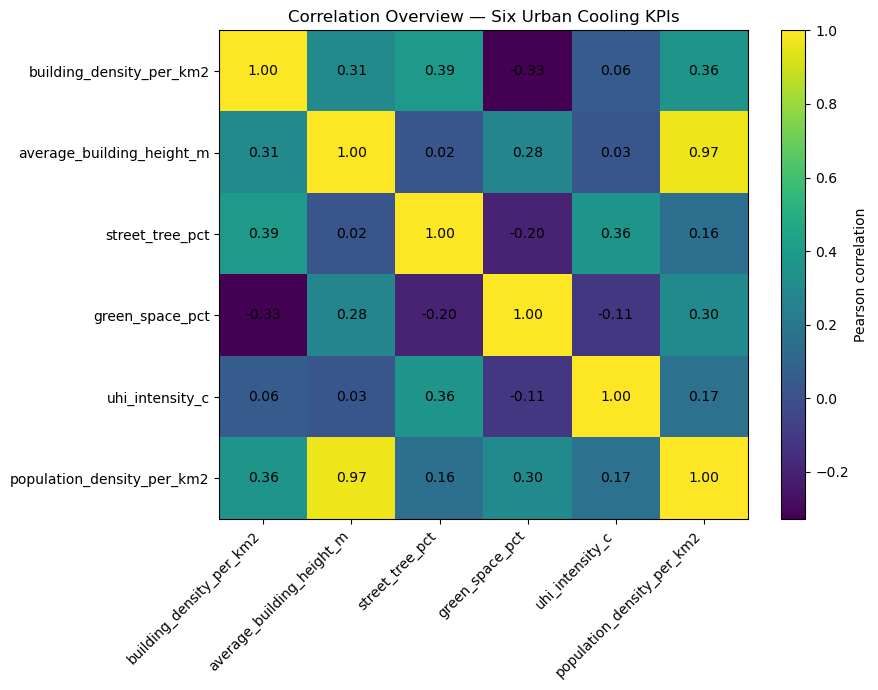

In [90]:
import matplotlib.pyplot as plt

corr_matrix = df[kpi_columns].corr()

print("Correlation matrix:")
display(corr_matrix.round(2))

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix.values, aspect="auto")

ax.set_xticks(range(len(kpi_columns)))
ax.set_yticks(range(len(kpi_columns)))
ax.set_xticklabels(kpi_columns, rotation=45, ha="right")
ax.set_yticklabels(kpi_columns)

for i in range(len(kpi_columns)):
    for j in range(len(kpi_columns)):
        ax.text(
            j, i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

ax.set_title("Correlation Overview — Six Urban Cooling KPIs")
fig.colorbar(im, ax=ax, label="Pearson correlation")
plt.tight_layout()
plt.show()

## 9.2 UHI Intensity vs Population Density

This comparison identifies cities where stronger urban heat coincides with a
higher concentration of residents.

The chart is used as a descriptive comparison rather than a causal test.

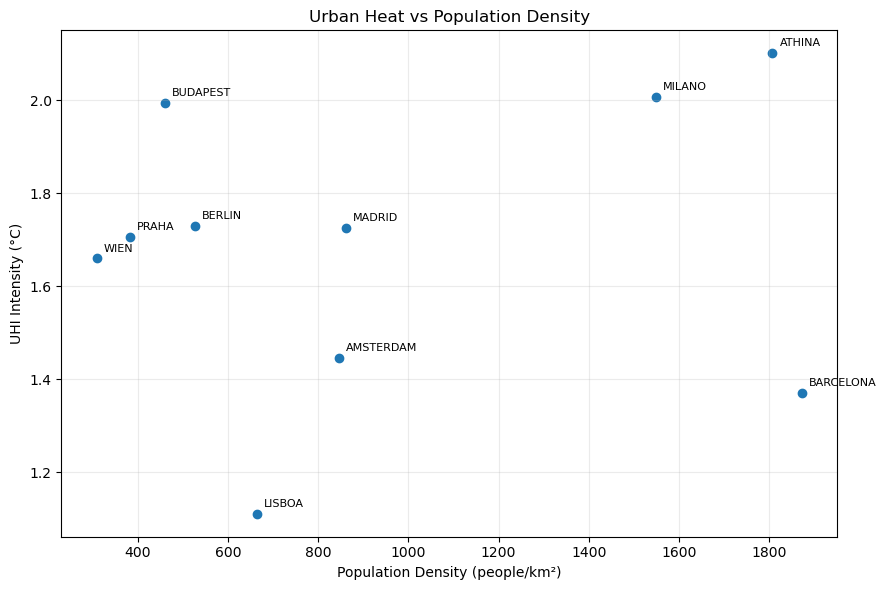

Descriptive correlation between population density and UHI intensity: 0.168


In [91]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    df["population_density_per_km2"],
    df["uhi_intensity_c"]
)

for _, row in df.iterrows():
    ax.annotate(
        row["city"],
        (
            row["population_density_per_km2"],
            row["uhi_intensity_c"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

ax.set_xlabel("Population Density (people/km²)")
ax.set_ylabel("UHI Intensity (°C)")
ax.set_title("Urban Heat vs Population Density")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

uhi_population_corr = (
    df[["population_density_per_km2", "uhi_intensity_c"]]
    .corr()
    .iloc[0, 1]
)

print(
    "Descriptive correlation between population density "
    f"and UHI intensity: {uhi_population_corr:.3f}"
)

## 9.3 Priority Score Driver Profile

The Priority Score is a composite of six equal-weight normalized indicators.
To explain *why* cities rank differently, the contribution of each KPI is
shown separately.

This is a decomposition of the model, not an independent correlation test.

Priority-score driver profile:


,Building Density,Building Height,Street-Tree Deficit,Green-Space Deficit,UHI Intensity,Population Density
city,,,,,,
ATHINA,0.710,0.856,0.647,0.027,1.000,0.959
MILANO,0.433,0.790,0.257,0.957,0.906,0.794
AMSTERDAM,1.000,0.443,0.406,1.000,0.338,0.343
BARCELONA,0.288,1.000,0.506,0.000,0.262,1.000
MADRID,0.000,0.566,0.939,0.257,0.620,0.354
BUDAPEST,0.275,0.079,0.395,0.599,0.891,0.096
WIEN,0.098,0.059,0.979,0.616,0.554,0.000
LISBOA,0.275,0.374,1.000,0.294,0.000,0.227
PRAHA,0.233,0.000,0.609,0.497,0.602,0.047


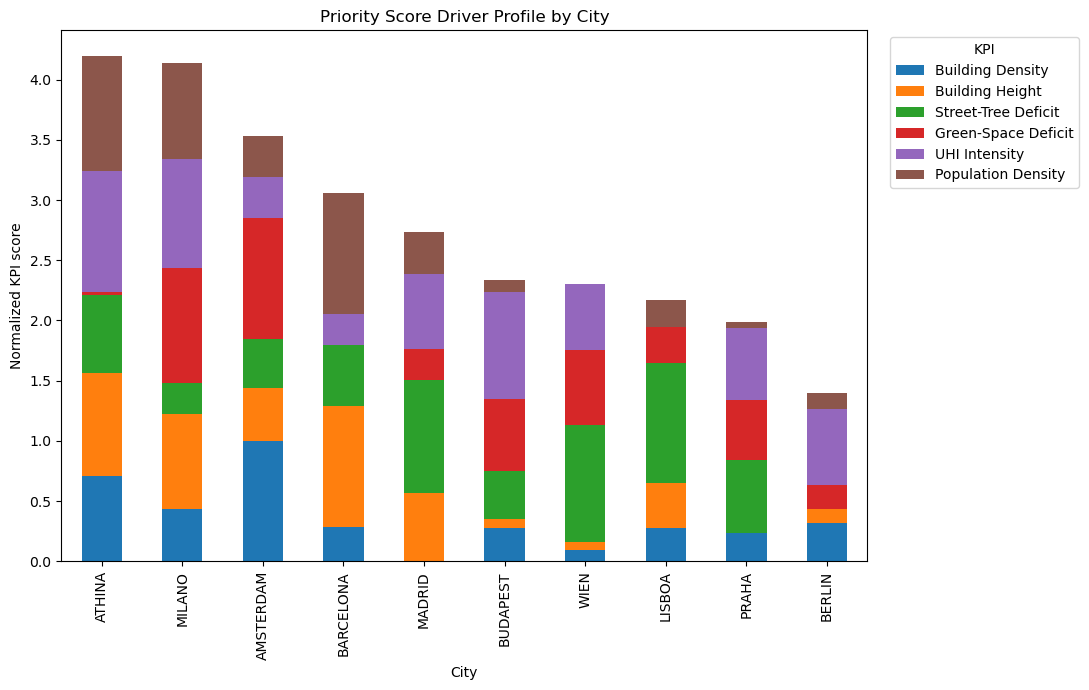

In [92]:
score_label_map = {
    "building_density_per_km2_score": "Building Density",
    "average_building_height_m_score": "Building Height",
    "street_tree_pct_score": "Street-Tree Deficit",
    "green_space_pct_score": "Green-Space Deficit",
    "uhi_intensity_c_score": "UHI Intensity",
    "population_density_per_km2_score": "Population Density"
}

driver_profile = (
    df[["city", "priority_rank"] + score_columns]
    .sort_values("priority_rank")
    .set_index("city")
)

driver_profile_display = driver_profile[score_columns].rename(
    columns=score_label_map
)

print("Priority-score driver profile:")
display(driver_profile_display.round(3))

fig, ax = plt.subplots(figsize=(11, 7))

driver_profile_display.plot(
    kind="bar",
    stacked=True,
    ax=ax
)

ax.set_xlabel("City")
ax.set_ylabel("Normalized KPI score")
ax.set_title("Priority Score Driver Profile by City")
ax.legend(
    title="KPI",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

## 9.4 City-Level Driver Summary

For each city, the strongest two normalized vulnerability drivers are identified.
This provides a transparent bridge from the analytical model to the intervention
recommendation.

In [93]:
def top_two_drivers(row):
    values = row[score_columns].sort_values(ascending=False)
    first = score_label_map[values.index[0]]
    second = score_label_map[values.index[1]]
    return pd.Series({
        "primary_driver": first,
        "secondary_driver": second
    })

driver_summary = df.apply(top_two_drivers, axis=1)

df = pd.concat([df, driver_summary], axis=1)

driver_summary_table = (
    df[
        [
            "city",
            "priority_score",
            "priority_rank",
            "primary_driver",
            "secondary_driver"
        ]
    ]
    .sort_values("priority_rank")
    .reset_index(drop=True)
)

display(driver_summary_table.round(3))

,city,priority_score,priority_rank,primary_driver,secondary_driver
0,ATHINA,0.700,1,UHI Intensity,Population Density
1,MILANO,0.689,2,Green-Space Deficit,UHI Intensity
2,AMSTERDAM,0.588,3,Building Density,Green-Space Deficit
3,BARCELONA,0.509,4,Building Height,Population Density
4,MADRID,0.456,5,Street-Tree Deficit,UHI Intensity
5,BUDAPEST,0.389,6,UHI Intensity,Green-Space Deficit
6,WIEN,0.384,7,Street-Tree Deficit,Green-Space Deficit
7,LISBOA,0.361,8,Street-Tree Deficit,Building Height
8,PRAHA,0.331,9,Street-Tree Deficit,UHI Intensity
9,BERLIN,0.234,10,UHI Intensity,Building Density


# 10. City-Specific Cooling Recommendations

Recommendations are based on the final KPI profiles and the strongest city-level
vulnerability patterns. They are phrased as concrete urban-cooling actions rather
than restating the general project goal.

In [109]:
recommendation_map = {
    "ATHINA": "Expand targeted cooling and shade",
    "MILANO": "Expand green infrastructure",
    "AMSTERDAM": "Expand green infrastructure",
    "BARCELONA": "Target cooling in high-density areas",
    "MADRID": "Expand street-tree coverage",
    "BUDAPEST": "Strengthen urban cooling and tree canopy",
    "WIEN": "Expand green infrastructure and street-tree coverage",
    "LISBOA": "Expand street-tree coverage",
    "PRAHA": "Strengthen green infrastructure and shade",
    "BERLIN": "Target cooling in dense built-up areas"
}

df["recommended_intervention"] = df["city"].map(recommendation_map)

if df["recommended_intervention"].isna().any():
    missing_cities = df.loc[
        df["recommended_intervention"].isna(),
        "city"
    ].tolist()
    raise ValueError(
        f"Missing recommendation for cities: {missing_cities}"
    )

intervention_table = (
    df[
        [
            "city",
            "priority_score",
            "priority_rank",
            "primary_driver",
            "secondary_driver",
            "recommended_intervention"
        ]
    ]
    .sort_values("priority_rank")
    .reset_index(drop=True)
)

display(intervention_table.round(3))

,city,priority_score,priority_rank,primary_driver,secondary_driver,recommended_intervention
0,ATHINA,0.700,1,UHI Intensity,Population Density,Expand targeted cooling and shade
1,MILANO,0.689,2,Green-Space Deficit,UHI Intensity,Expand green infrastructure
2,AMSTERDAM,0.588,3,Building Density,Green-Space Deficit,Expand green infrastructure
3,BARCELONA,0.509,4,Building Height,Population Density,Target cooling in high-density areas
4,MADRID,0.456,5,Street-Tree Deficit,UHI Intensity,Expand street-tree coverage
5,BUDAPEST,0.389,6,UHI Intensity,Green-Space Deficit,Strengthen urban cooling and tree canopy
6,WIEN,0.384,7,Street-Tree Deficit,Green-Space Deficit,Expand green infrastructure and street-tree co...
7,LISBOA,0.361,8,Street-Tree Deficit,Building Height,Expand street-tree coverage
8,PRAHA,0.331,9,Street-Tree Deficit,UHI Intensity,Strengthen green infrastructure and shade
9,BERLIN,0.234,10,UHI Intensity,Building Density,Target cooling in dense built-up areas


# 11. IMDC 2021–2024 — Supporting Context

Copernicus Imperviousness Change (IMDC) is retained as a supporting indicator.
It is **not** included in the Priority Score because the main six-KPI framework
uses the consistent baseline indicators available across all ten cities.

## Find IMDC 2021–2024 Processing

# IMDC Analysis: Land Cover Change (2021–2024)

This section compares impervious surface changes between 2021 and 2024 using Copernicus IMDC data.

## 1. IMDC Data Preparation

### 1.1 Select Required IMDC Tiles

In [110]:
from pathlib import Path
from zipfile import ZipFile
import geopandas as gpd
import rasterio

data_raw = Path("../Data_Raw")
urban_atlas = data_raw / "urban_atlas"

# Correct city names from Urban Atlas folder names
city_names = {
    "AMSTERDAM": "Amsterdam",
    "ATHINA": "Athens",
    "BARCELONA": "Barcelona",
    "BERLIN": "Berlin",
    "BUDAPEST": "Budapest",
    "LISBOA": "Lisbon",
    "MADRID": "Madrid",
    "MILANO": "Milan",
    "PRAHA": "Prague",
    "WIEN": "Vienna"
}

zip_files = list((data_raw / "Results-6").glob("*.zip"))
zip_files += list((data_raw / "Results-7").glob("*.zip"))

results_tiles = []

for fgb in urban_atlas.rglob("*.fgb"):

    folder_name = fgb.parent.name.upper()

    city = None
    for key, value in city_names.items():
        if f"_{key}_" in f"_{folder_name}_":
            city = value
            break

    if city is None:
        print("City not recognized:", folder_name)
        continue

    gdf = gpd.read_file(fgb)
    minx, miny, maxx, maxy = gdf.total_bounds

    for zip_file in zip_files:

        try:
            with ZipFile(zip_file) as z:
                tif_files = [
                    n for n in z.namelist()
                    if n.lower().endswith(".tif")
                ]

                if not tif_files:
                    continue

                tif_name = tif_files[0]

                with rasterio.open(
                    f"zip://{zip_file}!{tif_name}"
                ) as src:

                    b = src.bounds

                    intersects = not (
                        b.right < minx or
                        b.left > maxx or
                        b.top < miny or
                        b.bottom > maxy
                    )

                    if intersects:
                        results_tiles.append({
                            "city": city,
                            "zip_file": zip_file.name
                        })

        except Exception:
            pass

# Remove duplicates
results_tiles = list({
    (r["city"], r["zip_file"]): r
    for r in results_tiles
}.values())

for r in sorted(results_tiles, key=lambda x: (x["city"], x["zip_file"])):
    print(r["city"], "→", r["zip_file"])

Amsterdam → CLMS_NVLCC_IMDC_C2021-2024_R20m_E39N32_03035_V01_R01.zip
Amsterdam → CLMS_NVLCC_IMDC_C2021-2024_R20m_E39N33_03035_V01_R01.zip
Amsterdam → CLMS_NVLCC_IMDC_C2021-2024_R20m_E40N32_03035_V01_R01.zip
Amsterdam → CLMS_NVLCC_IMDC_C2021-2024_R20m_E40N33_03035_V01_R01.zip
Athens → CLMS_NVLCC_IMDC_C2021-2024_R20m_E55N17_03035_V01_R01.zip
Athens → CLMS_NVLCC_IMDC_C2021-2024_R20m_E55N18_03035_V01_R01.zip
Barcelona → CLMS_NVLCC_IMDC_C2021-2024_R20m_E36N20_03035_V01_R01.zip
Barcelona → CLMS_NVLCC_IMDC_C2021-2024_R20m_E36N21_03035_V01_R01.zip
Barcelona → CLMS_NVLCC_IMDC_C2021-2024_R20m_E37N20_03035_V01_R01.zip
Barcelona → CLMS_NVLCC_IMDC_C2021-2024_R20m_E37N21_03035_V01_R01.zip
Berlin → CLMS_NVLCC_IMDC_C2021-2024_R20m_E44N32_03035_V01_R01.zip
Berlin → CLMS_NVLCC_IMDC_C2021-2024_R20m_E44N33_03035_V01_R01.zip
Berlin → CLMS_NVLCC_IMDC_C2021-2024_R20m_E45N32_03035_V01_R01.zip
Berlin → CLMS_NVLCC_IMDC_C2021-2024_R20m_E45N33_03035_V01_R01.zip
Berlin → CLMS_NVLCC_IMDC_C2021-2024_R20m_E46N32_0303

### 1.2 Save Selected IMDC Tiles

In [111]:
import pandas as pd

tiles_df = pd.DataFrame(results_tiles)

print("Number of selected tiles:", len(tiles_df))

print("\nTiles per city:")
print(
    tiles_df.groupby("city")["zip_file"]
    .nunique()
    .sort_index()
)

tiles_df.to_csv(
    "../Data_Processed/IMDC_required_tiles.csv",
    index=False
)

print("\nSaved:")
print("../Data_Processed/IMDC_required_tiles.csv")

Number of selected tiles: 40

Tiles per city:
city
Amsterdam    4
Athens       2
Barcelona    4
Berlin       6
Budapest     4
Lisbon       4
Madrid       6
Milan        2
Prague       4
Vienna       4
Name: zip_file, dtype: int64

Saved:
../Data_Processed/IMDC_required_tiles.csv


In [112]:
from pathlib import Path
import pandas as pd

tiles_df = pd.read_csv("../Data_Processed/IMDC_required_tiles.csv")

print(tiles_df.head())
print("\nTotal:", len(tiles_df))
print("\nCities:", tiles_df["city"].nunique())

       city                                           zip_file
0  Budapest  CLMS_NVLCC_IMDC_C2021-2024_R20m_E49N27_03035_V...
1  Budapest  CLMS_NVLCC_IMDC_C2021-2024_R20m_E50N27_03035_V...
2  Budapest  CLMS_NVLCC_IMDC_C2021-2024_R20m_E49N28_03035_V...
3  Budapest  CLMS_NVLCC_IMDC_C2021-2024_R20m_E50N28_03035_V...
4    Vienna  CLMS_NVLCC_IMDC_C2021-2024_R20m_E47N27_03035_V...

Total: 40

Cities: 10


## 1.3 IMDC Data Preparation – Clip Tiles to City Boundaries

### 1.4 Create City-Level IMDC Mosaics

## 2. IMDC Analysis – Land Cover Change (2021–2024)

### Initial Raster Validation

This step checks the basic raster statistics for each city-level IMDC file.

We verify the minimum value, maximum value, mean value, and number of valid pixels before interpreting the IMDC change classes.

In [113]:
from pathlib import Path
import rasterio
import numpy as np

imdc_dir = Path("../Data_Processed/IMDC")

for city_dir in sorted(imdc_dir.iterdir()):

    if not city_dir.is_dir():
        continue

    tif = city_dir / f"{city_dir.name}_IMDC_2021_2024.tif"

    with rasterio.open(tif) as src:
        data = src.read(1, masked=True)

        print(
            city_dir.name,
            "→",
            "min:", data.min(),
            "max:", data.max(),
            "mean:", round(float(data.mean()), 3),
            "valid pixels:", data.count()
        )

Amsterdam → min: 0 max: 255 mean: 97.311 valid pixels: 15396024
Athens → min: 0 max: 255 mean: 89.87 valid pixels: 9304837
Barcelona → min: 0 max: 255 mean: 84.097 valid pixels: 13827147
Berlin → min: 0 max: 201 mean: 103.748 valid pixels: 41020265
Budapest → min: 0 max: 201 mean: 91.679 valid pixels: 32536616
Lisbon → min: 0 max: 255 mean: 108.099 valid pixels: 18622784
Madrid → min: 0 max: 201 mean: 109.915 valid pixels: 33457019
Milan → min: 0 max: 201 mean: 93.239 valid pixels: 13942044
Prague → min: 0 max: 201 mean: 99.1 valid pixels: 27341190
Vienna → min: 0 max: 201 mean: 118.666 valid pixels: 38645250


### Raster Value and Data Type Validation

This step checks the raster data type, NoData value, and a sample of unique raster values.

These checks help confirm that the IMDC rasters were loaded correctly before interpreting the encoded change classes.

In [114]:
from pathlib import Path
import rasterio
import numpy as np

imdc_dir = Path("../Data_Processed/IMDC")

for city_dir in sorted(imdc_dir.iterdir()):

    if not city_dir.is_dir():
        continue

    tif = city_dir / f"{city_dir.name}_IMDC_2021_2024.tif"

    with rasterio.open(tif) as src:

        data = src.read(1)

        print(
            city_dir.name,
            "→",
            "dtype:", data.dtype,
            "nodata:", src.nodata,
            "unique sample:", np.unique(data)[:15]
        )

Amsterdam → dtype: uint8 nodata: None unique sample: [ 0 65 69 70 74 75 76 79 80 83 84 85 86 87 88]
Athens → dtype: uint8 nodata: None unique sample: [ 0 77 78 79 80 81 82 83 84 85 86 87 88 89 90]
Barcelona → dtype: uint8 nodata: None unique sample: [ 0 67 80 84 87 89 90 91 92 93 94 95 96 97 98]
Berlin → dtype: uint8 nodata: None unique sample: [ 0  1 42 43 47 48 50 57 60 63 65 70 71 73 74]
Budapest → dtype: uint8 nodata: None unique sample: [ 0  5 28 30 38 44 60 68 75 76 77 81 82 83 84]
Lisbon → dtype: uint8 nodata: None unique sample: [ 0 66 67 72 73 77 78 79 80 81 82 83 84 85 86]
Madrid → dtype: uint8 nodata: None unique sample: [ 0 39 42 61 69 70 71 72 73 74 76 77 78 79 80]
Milan → dtype: uint8 nodata: None unique sample: [ 0 48 56 64 70 73 74 75 77 78 79 80 81 82 83]
Prague → dtype: uint8 nodata: None unique sample: [ 0 46 49 53 64 65 68 76 78 79 81 82 83 84 85]
Vienna → dtype: uint8 nodata: None unique sample: [ 0  9 10 13 26 28 35 37 42 43 51 69 76 77 78]


## 3. IMDC Analysis – Initial City-Level Summary (2021 -2024)

This step summarizes the Copernicus Imperviousness Change (IMDC) data for each city.

We calculate:
- Mean encoded change
- Percentage of area with increased imperviousness
- Percentage of area with decreased imperviousness
- Percentage of unchanged impervious area
- Percentage of unchanged non-impervious area

This is an exploratory step to understand the IMDC data before using it in the final priority model.

In [115]:
# ==========================================
# IMDC ANALYSIS — INITIAL CITY-LEVEL SUMMARY
# 2021–2024
# ==========================================

import pandas as pd
from pathlib import Path
import rasterio
import numpy as np

imdc_dir = Path("../Data_Processed/IMDC")

results = []

for city_dir in sorted(imdc_dir.iterdir()):

    if not city_dir.is_dir():
        continue

    tif = city_dir / f"{city_dir.name}_IMDC_2021_2024.tif"

    with rasterio.open(tif) as src:
        data = src.read(1)

    # Exclude outside area
    valid = data[data != 255]

    total_pixels = len(valid)

    # IMDC classes according to Copernicus:
    # 0–99   = decreased imperviousness
    # 100    = unchanged impervious areas
    # 101–200 = increased imperviousness
    # 201    = unchanged non-impervious areas

    decreased = valid[(valid >= 0) & (valid <= 99)]
    unchanged_impervious = valid[valid == 100]
    increased = valid[(valid >= 101) & (valid <= 200)]
    unchanged_non_impervious = valid[valid == 201]

    results.append({
        "city": city_dir.name,

        "increased_impervious_pct": round(
            len(increased) / total_pixels * 100, 2
        ),

        "decreased_impervious_pct": round(
            len(decreased) / total_pixels * 100, 2
        ),

        "unchanged_impervious_pct": round(
            len(unchanged_impervious) / total_pixels * 100, 2
        ),

        "unchanged_non_impervious_pct": round(
            len(unchanged_non_impervious) / total_pixels * 100, 2
        )
    })

imdc_summary = pd.DataFrame(results)

print("========== IMDC CITY-LEVEL SUMMARY ==========")

display(imdc_summary.round(2))

========== IMDC CITY-LEVEL SUMMARY ==========


,city,increased_impervious_pct,decreased_impervious_pct,unchanged_impervious_pct,unchanged_non_impervious_pct
0,Amsterdam,0.18,45.98,11.05,42.79
1,Athens,0.18,47.23,15.91,36.69
2,Barcelona,0.13,52.16,11.85,35.87
3,Berlin,0.10,44.76,7.14,48.00
4,Budapest,0.11,50.83,7.00,42.06
5,Lisbon,0.18,41.03,10.22,48.57
6,Madrid,0.14,41.15,8.19,50.52
7,Milan,0.27,44.15,18.65,36.94
8,Prague,0.14,47.30,6.66,45.90
9,Vienna,0.09,37.75,6.32,55.84


## 4, IMDC Analysis – Signed Change Exploration (2021 -2024)

This step converts the encoded IMDC values into signed percentage change values.

The purpose is exploratory: to understand the direction and magnitude of imperviousness change across cities.

Note:
The resulting mean net change is NOT used directly in the final Priority Score.
The IMDC encoding requires careful interpretation before selecting a final city-level indicator.

In [116]:
from pathlib import Path
import rasterio
import numpy as np
import pandas as pd

imdc_dir = Path("../Data_Processed/IMDC")

results = []

for city_dir in sorted(imdc_dir.iterdir()):

    if not city_dir.is_dir():
        continue

    tif = city_dir / f"{city_dir.name}_IMDC_2021_2024.tif"

    with rasterio.open(tif) as src:
        data = src.read(1)

    # Keep only actual change/no-change impervious classes
    valid = data[(data >= 0) & (data <= 200)]

    # Convert encoded values to signed percentage change
    signed_change = valid.astype(float) - 100

    increased = signed_change[signed_change > 0]
    decreased = signed_change[signed_change < 0]
    unchanged = signed_change[signed_change == 0]

    results.append({
        "city": city_dir.name,
        "mean_net_change_pct": round(float(signed_change.mean()), 2),
        "increased_area_pct": round(
            len(increased) / len(valid) * 100, 2
        ),
        "decreased_area_pct": round(
            len(decreased) / len(valid) * 100, 2
        ),
        "unchanged_area_pct": round(
            len(unchanged) / len(valid) * 100, 2
        )
    })

imdc_final = pd.DataFrame(results)

imdc_final

,city,mean_net_change_pct,increased_area_pct,decreased_area_pct,unchanged_area_pct
0,Amsterdam,-80.27,0.32,80.37,19.32
1,Athens,-74.54,0.28,74.60,25.12
2,Barcelona,-81.28,0.20,81.33,18.48
3,Berlin,-86.03,0.19,86.08,13.73
4,Budapest,-87.67,0.19,87.73,12.07
5,Lisbon,-79.68,0.35,79.78,19.88
6,Madrid,-83.09,0.29,83.16,16.55
7,Milan,-69.88,0.43,70.00,29.57
8,Prague,-87.35,0.26,87.43,12.32
9,Vienna,-85.42,0.21,85.48,14.31


## 5. IMDC City-Level Indicators

This step converts the Copernicus Imperviousness Change (IMDC) raster
into three comparable city-level indicators:

- `impervious_increase_pct`: percentage of comparable area with increased imperviousness
- `impervious_decrease_pct`: percentage of comparable area with decreased imperviousness
- `stable_impervious_pct`: percentage of comparable area with stable imperviousness

The denominator includes only pixels classified within the IMDC change
range (0–200). Unchanged non-impervious areas (201) and outside areas (255)
are excluded.

These indicators will be compared with the existing heat, exposure,
and green-space indicators before deciding whether IMDC should be included
in the final Priority Score.

In [117]:
from pathlib import Path
import rasterio
import numpy as np
import pandas as pd

imdc_dir = Path("../Data_Processed/IMDC")

results = []

for city_dir in sorted(imdc_dir.iterdir()):

    if not city_dir.is_dir():
        continue

    tif = city_dir / f"{city_dir.name}_IMDC_2021_2024.tif"

    with rasterio.open(tif) as src:
        data = src.read(1)

    # Keep only comparable IMDC classes: 0–200
    valid = data[(data >= 0) & (data <= 200)]

    total = len(valid)

    increased = np.sum((valid >= 101) & (valid <= 200))
    decreased = np.sum((valid >= 0) & (valid <= 99))
    stable_impervious = np.sum(valid == 100)

    results.append({
        "city": city_dir.name,
        "impervious_increase_pct": round(
            increased / total * 100, 2
        ),
        "impervious_decrease_pct": round(
            decreased / total * 100, 2
        ),
        "stable_impervious_pct": round(
            stable_impervious / total * 100, 2
        ),
        "comparable_pixels": total
    })

imdc_indicators = pd.DataFrame(results)

imdc_indicators

,city,impervious_increase_pct,impervious_decrease_pct,stable_impervious_pct,comparable_pixels
0,Amsterdam,0.32,80.37,19.32,8807228
1,Athens,0.28,74.60,25.12,5890786
2,Barcelona,0.20,81.33,18.48,8867929
3,Berlin,0.19,86.08,13.73,21330213
4,Budapest,0.19,87.73,12.07,18852473
5,Lisbon,0.35,79.78,19.88,9576220
6,Madrid,0.29,83.16,16.55,16554468
7,Milan,0.43,70.00,29.57,8792024
8,Prague,0.26,87.43,12.32,14792101
9,Vienna,0.21,85.48,14.31,17067664


## 6. IMDC Integration with Urban Cooling Priority

IMDC imperviousness change is compared with the final urban cooling priority score
to assess whether recent land-cover change provides additional information.

In [118]:
# ============================================================
# FINAL IMDC INTEGRATION WITH URBAN COOLING PRIORITY
# ============================================================

comparison = intervention_table[
    [
        "city",
        "priority_score",
        "priority_rank",
        "recommended_intervention"
    ]
].copy()

# Standardize priority-model city names
city_map = {
    "ATHINA": "ATHENS",
    "MILANO": "MILAN",
    "WIEN": "VIENNA",
    "LISBOA": "LISBON",
    "PRAHA": "PRAGUE"
}

comparison["city_key"] = (
    comparison["city"]
    .str.upper()
    .str.strip()
    .replace(city_map)
)

# Standardize IMDC city names
imdc_compare = imdc_indicators.copy()

imdc_compare["city_key"] = (
    imdc_compare["city"]
    .str.upper()
    .str.strip()
)

# Merge
comparison = comparison.merge(
    imdc_compare[
        [
            "city_key",
            "impervious_increase_pct",
            "impervious_decrease_pct",
            "stable_impervious_pct"
        ]
    ],
    on="city_key",
    how="left"
)

comparison = comparison.drop(columns=["city_key"])

comparison = (
    comparison
    .sort_values("priority_rank")
    .reset_index(drop=True)
)

print("========== FINAL IMDC INTEGRATION ==========")

display(comparison.round(3))

# Correlation
correlation = (
    comparison[
        ["impervious_increase_pct", "priority_score"]
    ]
    .corr()
    .iloc[0, 1]
)

print(
    f"\nCorrelation between impervious increase "
    f"and priority score: {correlation:.3f}"
)

========== FINAL IMDC INTEGRATION ==========


,city,priority_score,priority_rank,recommended_intervention,impervious_increase_pct,impervious_decrease_pct,stable_impervious_pct
0,ATHINA,0.700,1,Expand targeted cooling and shade,0.28,74.60,25.12
1,MILANO,0.689,2,Expand green infrastructure,0.43,70.00,29.57
2,AMSTERDAM,0.588,3,Expand green infrastructure,0.32,80.37,19.32
3,BARCELONA,0.509,4,Target cooling in high-density areas,0.20,81.33,18.48
4,MADRID,0.456,5,Expand street-tree coverage,0.29,83.16,16.55
5,BUDAPEST,0.389,6,Strengthen urban cooling and tree canopy,0.19,87.73,12.07
6,WIEN,0.384,7,Expand green infrastructure and street-tree co...,0.21,85.48,14.31
7,LISBOA,0.361,8,Expand street-tree coverage,0.35,79.78,19.88
8,PRAHA,0.331,9,Strengthen green infrastructure and shade,0.26,87.43,12.32
9,BERLIN,0.234,10,Target cooling in dense built-up areas,0.19,86.08,13.73



Correlation between impervious increase and priority score: 0.575


In [119]:
# Save final comparison table
comparison.to_csv(
    "../Data_Processed/city_level_comparison_with_imdc.csv",
    index=False
)

print("Saved:")
print("../Data_Processed/city_level_comparison_with_imdc.csv")

Saved:
../Data_Processed/city_level_comparison_with_imdc.csv


## 7. Final City-Level Comparison with IMDC

The final comparison combines the existing urban heat vulnerability
indicators with the IMDC imperviousness increase indicator.

IMDC is retained as an additional diagnostic indicator and is not
included in the current Priority Score.

In [120]:
comparison

,city,priority_score,priority_rank,recommended_intervention,impervious_increase_pct,impervious_decrease_pct,stable_impervious_pct
0,ATHINA,0.699785,1,Expand targeted cooling and shade,0.28,74.60,25.12
1,MILANO,0.689442,2,Expand green infrastructure,0.43,70.00,29.57
2,AMSTERDAM,0.588412,3,Expand green infrastructure,0.32,80.37,19.32
3,BARCELONA,0.509404,4,Target cooling in high-density areas,0.20,81.33,18.48
4,MADRID,0.456055,5,Expand street-tree coverage,0.29,83.16,16.55
5,BUDAPEST,0.389235,6,Strengthen urban cooling and tree canopy,0.19,87.73,12.07
6,WIEN,0.384382,7,Expand green infrastructure and street-tree co...,0.21,85.48,14.31
7,LISBOA,0.361484,8,Expand street-tree coverage,0.35,79.78,19.88
8,PRAHA,0.331381,9,Strengthen green infrastructure and shade,0.26,87.43,12.32
9,BERLIN,0.233595,10,Target cooling in dense built-up areas,0.19,86.08,13.73


# 12. Final Tableau-Ready Dataset

The final Tableau file contains the six original KPIs, their normalized scores,
the Priority Score and Rank, the two strongest analytical drivers, the final
city-specific recommendation, and the supporting IMDC indicators.

Using one final CSV avoids the need to relate a separate recommendation table
inside Tableau.

In [121]:
tableau_ready = df.copy()

# City key used only for the IMDC merge
city_name_map = {
    "ATHINA": "ATHENS",
    "MILANO": "MILAN",
    "WIEN": "VIENNA",
    "LISBOA": "LISBON",
    "PRAHA": "PRAGUE"
}

tableau_ready["city_key"] = (
    tableau_ready["city"]
    .str.upper()
    .str.strip()
    .replace(city_name_map)
)

imdc_compare = imdc_indicators.copy()
imdc_compare["city_key"] = (
    imdc_compare["city"]
    .str.upper()
    .str.strip()
)

tableau_ready = tableau_ready.merge(
    imdc_compare[
        [
            "city_key",
            "impervious_increase_pct",
            "impervious_decrease_pct",
            "stable_impervious_pct"
        ]
    ],
    on="city_key",
    how="left"
)

tableau_ready = tableau_ready.drop(columns=["city_key"])

tableau_columns = [
    "city",

    # Original six KPIs
    "building_density_per_km2",
    "average_building_height_m",
    "street_tree_pct",
    "green_space_pct",
    "uhi_intensity_c",
    "population_density_per_km2",

    # Normalized KPI scores
    "building_density_per_km2_score",
    "average_building_height_m_score",
    "street_tree_pct_score",
    "green_space_pct_score",
    "uhi_intensity_c_score",
    "population_density_per_km2_score",

    # Final priority model
    "priority_score",
    "priority_rank",

    # Analytical interpretation
    "primary_driver",
    "secondary_driver",
    "recommended_intervention",

    # IMDC 2021–2024
    "impervious_increase_pct",
    "impervious_decrease_pct",
    "stable_impervious_pct"
]

tableau_ready = (
    tableau_ready[tableau_columns]
    .sort_values("priority_rank")
    .reset_index(drop=True)
)

print("========== FINAL TABLEAU-READY DATASET ==========")
print("Shape:", tableau_ready.shape)

display(tableau_ready.round(3))

========== FINAL TABLEAU-READY DATASET ==========
Shape: (10, 21)


,city,building_density_per_km2,average_building_height_m,street_tree_pct,green_space_pct,uhi_intensity_c,population_density_per_km2,building_density_per_km2_score,average_building_height_m_score,street_tree_pct_score,...,uhi_intensity_c_score,population_density_per_km2_score,priority_score,priority_rank,primary_driver,secondary_driver,recommended_intervention,impervious_increase_pct,impervious_decrease_pct,stable_impervious_pct
0,ATHINA,343.281,9.770,3.254,47.223,2.101,1807.100,0.710,0.856,0.647,...,1.000,0.959,0.700,1,UHI Intensity,Population Density,Expand targeted cooling and shade,0.28,74.60,25.12
1,MILANO,235.562,9.383,4.815,9.927,2.008,1549.623,0.433,0.790,0.257,...,0.906,0.794,0.689,2,Green-Space Deficit,UHI Intensity,Expand green infrastructure,0.43,70.00,29.57
2,AMSTERDAM,456.255,7.356,4.219,8.189,1.446,845.656,1.000,0.443,0.406,...,0.338,0.343,0.588,3,Building Density,Green-Space Deficit,Expand green infrastructure,0.32,80.37,19.32
3,BARCELONA,179.012,10.610,3.817,48.296,1.370,1871.973,0.288,1.000,0.506,...,0.262,1.000,0.509,4,Building Height,Population Density,Target cooling in high-density areas,0.20,81.33,18.48
4,MADRID,66.770,8.079,2.091,37.972,1.725,862.212,0.000,0.566,0.939,...,0.620,0.354,0.456,5,Street-Tree Deficit,UHI Intensity,Expand street-tree coverage,0.29,83.16,16.55
5,BUDAPEST,173.763,5.231,4.261,24.274,1.994,459.546,0.275,0.079,0.395,...,0.891,0.096,0.389,6,UHI Intensity,Green-Space Deficit,Strengthen urban cooling and tree canopy,0.19,87.73,12.07
6,WIEN,104.985,5.115,1.929,23.589,1.660,308.737,0.098,0.059,0.979,...,0.554,0.000,0.384,7,Street-Tree Deficit,Green-Space Deficit,Expand green infrastructure and street-tree co...,0.21,85.48,14.31
7,LISBOA,173.805,6.953,1.846,36.515,1.111,663.334,0.275,0.374,1.000,...,0.000,0.227,0.361,8,Street-Tree Deficit,Building Height,Expand street-tree coverage,0.35,79.78,19.88
8,PRAHA,157.640,4.772,3.408,28.370,1.707,382.986,0.233,0.000,0.609,...,0.602,0.047,0.331,9,Street-Tree Deficit,UHI Intensity,Strengthen green infrastructure and shade,0.26,87.43,12.32
9,BERLIN,189.671,5.460,5.841,40.156,1.730,527.182,0.316,0.118,0.000,...,0.626,0.140,0.234,10,UHI Intensity,Building Density,Target cooling in dense built-up areas,0.19,86.08,13.73


In [122]:
# ==========================================
# EXPORT FINAL TABLEAU CSV
# ==========================================

final_csv_path = (
    PROJECT_DIR
    / "Data_Processed"
    / "Smart_Cities_Cooler_Futures_Tableau_CLEAN.csv"
)

final_csv_path.parent.mkdir(parents=True, exist_ok=True)

tableau_ready.to_csv(
    final_csv_path,
    index=False
)

print("Final Tableau CSV saved:")
print(final_csv_path)

Final Tableau CSV saved:
/Users/nedalgubran/Desktop/Project/Smart_Cities_Cooler_Futures/Data_Processed/Smart_Cities_Cooler_Futures_Tableau_CLEAN.csv


## 12.1 Final Validation

The final dataset is validated before it is used to rebuild the Tableau dashboards.

In [124]:
print("========== FINAL DATASET VALIDATION ==========")

print("\nShape:", tableau_ready.shape)
print("Number of cities:", tableau_ready["city"].nunique())

duplicate_columns = (
    tableau_ready.columns[
        tableau_ready.columns.duplicated()
    ].tolist()
)

print("Duplicate columns:", duplicate_columns)

print("\nMissing values:")
display(tableau_ready.isna().sum())

print("\nFinal priority ranking:")
display(
    tableau_ready[
        [
            "city",
            "priority_score",
            "priority_rank",
            "primary_driver",
            "secondary_driver",
            "recommended_intervention"
        ]
    ]
)

assert tableau_ready["city"].nunique() == 10
assert len(duplicate_columns) == 0
assert tableau_ready.isna().sum().sum() == 0

print("\n✅ ALL FINAL VALIDATION CHECKS PASSED.")

========== FINAL DATASET VALIDATION ==========

Shape: (10, 21)
Number of cities: 10
Duplicate columns: []

Missing values:


city                                0
building_density_per_km2            0
average_building_height_m           0
street_tree_pct                     0
green_space_pct                     0
uhi_intensity_c                     0
population_density_per_km2          0
building_density_per_km2_score      0
average_building_height_m_score     0
street_tree_pct_score               0
green_space_pct_score               0
uhi_intensity_c_score               0
population_density_per_km2_score    0
priority_score                      0
priority_rank                       0
primary_driver                      0
secondary_driver                    0
recommended_intervention            0
impervious_increase_pct             0
impervious_decrease_pct             0
stable_impervious_pct               0
dtype: int64


Final priority ranking:


,city,priority_score,priority_rank,primary_driver,secondary_driver,recommended_intervention
0,ATHINA,0.699785,1,UHI Intensity,Population Density,Expand targeted cooling and shade
1,MILANO,0.689442,2,Green-Space Deficit,UHI Intensity,Expand green infrastructure
2,AMSTERDAM,0.588412,3,Building Density,Green-Space Deficit,Expand green infrastructure
3,BARCELONA,0.509404,4,Building Height,Population Density,Target cooling in high-density areas
4,MADRID,0.456055,5,Street-Tree Deficit,UHI Intensity,Expand street-tree coverage
5,BUDAPEST,0.389235,6,UHI Intensity,Green-Space Deficit,Strengthen urban cooling and tree canopy
6,WIEN,0.384382,7,Street-Tree Deficit,Green-Space Deficit,Expand green infrastructure and street-tree co...
7,LISBOA,0.361484,8,Street-Tree Deficit,Building Height,Expand street-tree coverage
8,PRAHA,0.331381,9,Street-Tree Deficit,UHI Intensity,Strengthen green infrastructure and shade
9,BERLIN,0.233595,10,UHI Intensity,Building Density,Target cooling in dense built-up areas



✅ ALL FINAL VALIDATION CHECKS PASSED.


## Methodological Note

We use 2021 as the baseline year because the main datasets are consistently
available for all ten selected cities.

Copernicus IMDC data covering 2021–2024 is used as supporting context for recent
impervious-surface change. It is not added directly to the Priority Score.

The final Priority Score therefore remains a transparent equal-weight model of
the six validated baseline KPIs, while the comparative analysis and IMDC section
provide additional interpretation.